## **01 Data Loading And Validation**

Goals: By the end of this step, we must be 100% sure that:

- Both CSV files load correctly

- Skill columns are aligned (same 45 skills, same names)

- No missing / broken values

- Skill ranges make sense (courses: 0/1, students: 0–10)

- We produce clean objects to reuse later

<h3>Imports & display settings</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


<h3>Load datasets</h3>

In [2]:
courses_path = "../Data/Final Data/all-courses-hybrid-45-skills.csv"
students_path = "../Data/Final Data/student_responses.csv"

courses_df = pd.read_csv(courses_path)
students_df = pd.read_csv(students_path)

In [3]:
print("Courses shape:", courses_df.shape)
print("Students shape:", students_df.shape)

Courses shape: (20404, 53)
Students shape: (108, 46)


In [4]:
courses_df.head(2)

,course_title,rating,review_count,skills_list,platform,level,duration,skills_text,javascript,wordpress,technical product management,financial accounting,application development,system security,digital marketing,microsoft excel,regulations and compliance,market analysis,swift programming,people management,network architecture,theoretical computer science,bayesian network,negotiation,people analysis,search engine optimization,sap,machine learning software,user experience,database application,angular,basic descriptive statistics,jira,spatial analysis,interactive design,strategy and operations,big data,python programming,media strategy & planning,financial analysis,human learning,google app engine,writing,android development,software testing,risk management,game theory,web development,supply chain and logistics,user experience design,agile software development,internet of things,power bi
0,Google Cybersecurity,4.8,16400.0,"['databases', 'network architecture', 'risk ma...",coursera,1,78.21,databases | network architecture | risk manage...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,Google Data Analytics,4.8,133400.0,"['data visualization software', 'small data', ...",coursera,1,78.21,data visualization software | small data | big...,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
students_df.head(2)

,Timestamp,1) Javascript,2) Wordpress,3) Technical product management,4) Financial accounting,5) Application development,6) System security,7) Digital marketing,8) Microsoft excel,9) Regulations and compliance,10) Market analysis,11) Swift programming,12) People management,13) Network architecture,14) Theoretical computer science,15) Bayesian network,16) Negotiation,17) People analysis,18) Search engine optimization,19) Sap,20) machine learning software,21) User experience,22) Database application,23) Angular,24) Basic descriptive statistics,25) Jira,26) Spatial analysis,27) Interactive design,28) Strategy and operations,29) Big data,30) Python programming,31) Media strategy & planning,32) Financial analysis,33) Human learning,34) Google app engine,35) Writing,36) Android development,37) Software testing,38) Risk management,39) Game theory,40) Web development,41) Supply chain and logistics,42) User experience design,43) Agile software development,44) Internet of things,45) Power bi
0,11/26/2025 13:58:11,4,6,5,8,6,2,10,8,10,5,5,8,3,4,9,10,7,8,6,5,7,4,8,9,3,5,7,5,7,7,5,9,2,5,3,4,6,9,10,4,5,6,3,7,3
1,11/26/2025 14:02:25,7,3,5,7,6,4,8,9,4,10,2,7,8,8,7,6,8,8,3,7,5,8,1,7,1,7,7,7,7,9,7,8,5,4,8,1,8,8,1,7,7,6,5,7,7


<h3>Identify skill columns</h3>

In [6]:
non_skill_cols = [
    "course_title",
    "rating",
    "review_count",
    "skills_list",
    "platform",
    "level",
    "duration",
    "skills_text"
]

course_skill_cols = [c for c in courses_df.columns if c not in non_skill_cols]

len(course_skill_cols), course_skill_cols

(45,
 ['javascript',
  'wordpress',
  'technical product management',
  'financial accounting',
  'application development',
  'system security',
  'digital marketing',
  'microsoft excel',
  'regulations and compliance',
  'market analysis',
  'swift programming',
  'people management',
  'network architecture',
  'theoretical computer science',
  'bayesian network',
  'negotiation',
  'people analysis',
  'search engine optimization',
  'sap',
  'machine learning software',
  'user experience',
  'database application',
  'angular',
  'basic descriptive statistics',
  'jira',
  'spatial analysis',
  'interactive design',
  'strategy and operations',
  'big data',
  'python programming',
  'media strategy & planning',
  'financial analysis',
  'human learning',
  'google app engine',
  'writing',
  'android development',
  'software testing',
  'risk management',
  'game theory',
  'web development',
  'supply chain and logistics',
  'user experience design',
  'agile software develop

<h4>Student skill columns normalization</h4>

In [7]:
students_df_raw = students_df.copy()

def normalize_student_columns(df):
    rename_map = {}
    for col in df.columns:
        if ") " in col:
            skill = col.split(") ", 1)[1].strip().lower()
            rename_map[col] = skill
    return df.rename(columns=rename_map)

students_df = normalize_student_columns(students_df)
students_df.head(2)


,Timestamp,javascript,wordpress,technical product management,financial accounting,application development,system security,digital marketing,microsoft excel,regulations and compliance,market analysis,swift programming,people management,network architecture,theoretical computer science,bayesian network,negotiation,people analysis,search engine optimization,sap,machine learning software,user experience,database application,angular,basic descriptive statistics,jira,spatial analysis,interactive design,strategy and operations,big data,python programming,media strategy & planning,financial analysis,human learning,google app engine,writing,android development,software testing,risk management,game theory,web development,supply chain and logistics,user experience design,agile software development,internet of things,power bi
0,11/26/2025 13:58:11,4,6,5,8,6,2,10,8,10,5,5,8,3,4,9,10,7,8,6,5,7,4,8,9,3,5,7,5,7,7,5,9,2,5,3,4,6,9,10,4,5,6,3,7,3
1,11/26/2025 14:02:25,7,3,5,7,6,4,8,9,4,10,2,7,8,8,7,6,8,8,3,7,5,8,1,7,1,7,7,7,7,9,7,8,5,4,8,1,8,8,1,7,7,6,5,7,7


<h3>Align skill columns</h3>

In [8]:
student_skill_cols = [
    c for c in students_df.columns
    if c not in ["Timestamp"]
]

common_skills = sorted(set(course_skill_cols).intersection(student_skill_cols))

print("Course skills:", len(course_skill_cols))
print("Student skills:", len(student_skill_cols))
print("Common skills:", len(common_skills))


Course skills: 45
Student skills: 45
Common skills: 45


<h4>check mismatches</h4>

In [9]:
missing_in_students = set(course_skill_cols) - set(common_skills)
missing_in_courses = set(student_skill_cols) - set(common_skills)

print("Missing in students:", missing_in_students)
print("Missing in courses:", missing_in_courses)


Missing in students: set()
Missing in courses: set()


<h3>Value validation</h3>

<h4>Course skills</h4>

In [10]:
courses_df[common_skills].describe()

,agile software development,android development,angular,application development,basic descriptive statistics,bayesian network,big data,database application,digital marketing,financial accounting,financial analysis,game theory,google app engine,human learning,interactive design,internet of things,javascript,jira,machine learning software,market analysis,media strategy & planning,microsoft excel,negotiation,network architecture,people analysis,people management,power bi,python programming,regulations and compliance,risk management,sap,search engine optimization,software testing,spatial analysis,strategy and operations,supply chain and logistics,swift programming,system security,technical product management,theoretical computer science,user experience,user experience design,web development,wordpress,writing
count,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000,20404.000000
mean,0.010831,0.017840,0.009214,0.024995,0.026661,0.007744,0.010635,0.038816,0.013282,0.035875,0.036708,0.022643,0.054009,0.008038,0.008136,0.213978,0.031807,0.002500,0.024554,0.021711,0.025093,0.063223,0.002401,0.016222,0.008969,0.008969,0.025093,0.066556,0.005195,0.015242,0.014850,0.015144,0.019261,0.000882,0.025926,0.005979,0.006959,0.023133,0.017742,0.021907,0.026563,0.025632,0.001666,0.017889,0.014997
std,0.103510,0.132372,0.095548,0.156114,0.161096,0.087658,0.102580,0.193161,0.114481,0.185984,0.188050,0.148765,0.226041,0.089294,0.089832,0.410121,0.175492,0.049934,0.154765,0.145743,0.156412,0.243369,0.048947,0.126333,0.094281,0.094281,0.156412,0.249257,0.071891,0.122517,0.120955,0.122129,0.137444,0.029689,0.158919,0.077096,0.083134,0.150329,0.132014,0.146385,0.160808,0.158039,0.040788,0.132550,0.121544
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000

<h5>Quick hard check:</h5>

In [11]:
invalid_course_values = (
    ~courses_df[common_skills].isin([0, 1])
).sum().sum()

print("Invalid course skill values:", invalid_course_values)


Invalid course skill values: 0


<h4>Student skills</h4>

In [12]:
students_df[common_skills].describe()


,agile software development,android development,angular,application development,basic descriptive statistics,bayesian network,big data,database application,digital marketing,financial accounting,financial analysis,game theory,google app engine,human learning,interactive design,internet of things,javascript,jira,machine learning software,market analysis,media strategy & planning,microsoft excel,negotiation,network architecture,people analysis,people management,power bi,python programming,regulations and compliance,risk management,sap,search engine optimization,software testing,spatial analysis,strategy and operations,supply chain and logistics,swift programming,system security,technical product management,theoretical computer science,user experience,user experience design,web development,wordpress,writing
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.00000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.00000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,4.888889,4.472222,3.287037,5.138889,4.666667,3.527778,4.870370,6.851852,4.87037,4.611111,4.907407,4.398148,5.898148,5.305556,5.435185,5.268519,4.953704,3.750000,4.907407,5.203704,5.148148,6.287037,5.351852,4.87037,6.407407,6.250000,3.703704,5.777778,5.314815,5.888889,3.990741,5.722222,5.675926,3.694444,5.648148,4.287037,3.037037,4.842593,5.537037,5.648148,6.259259,6.101852,6.009259,4.111111,6.601852
std,2.958698,3.319324,2.854905,3.006095,3.007778,2.752937,2.983107,2.750751,2.73466,2.844353,2.937152,3.159143,3.261041,3.043173,3.014833,3.098406,2.739071,3.177388,2.617472,2.953722,2.928477,2.554274,3.121570,2.88111,2.986064,2.765356,2.964775,2.891603,3.110573,3.042789,3.239636,3.179471,2.841050,2.849687,3.103555,2.741345,2.682327,2.731478,2.965301,2.762617,2.930249,2.675398,3.009317,3.183877,2.692807
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,5.000000,3.00000,1.000000,2.000000,1.000000,3.000000,3.000000,3.000000,2.000000,3.000000,1.000000,3.000000,3.000000,2.000000,5.000000,2.750000,2.75000,4.750000,5.000000,1.000000,4.000000,3.000000,3.000000,1.000000,3.000000,4.000000,1.000000,3.000000,1.000000,1.000000,3.000000,3.750000,3.750000,4.750000,5.000000,3.750000,1.000000,5.000000
50%,5.000000,4.500000,2.000000,5.000000,5.000000,3.000000,5.000000,7.000000,5.00000,5.000000,5.000000,4.000000,6.000000,5.000000,5.500000,5.000000,5.000000,2.000000,5.000000,5.000000,5.000000,6.000000,5.500000,5.00000,7.000000,6.000000,2.500000,6.000000,5.000000,6.000000,3.000000,6.000000,6.000000,3.000000,6.000000,4.000000,1.500000,5.000000,5.500000,6.000000,7.000000,6.000000,6.000000,3.500000,7.000000
75%,7.000000,7.000000,5.000000,8.000000,7.000000,5.000000,7.000000,9.000000,7.00000,7.000000,7.000000,7.000000,10.000000,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,8.000000,8.000000,7.00000,9.000000,8.250000,6.000000,8.000000,8.000000,8.000000,6.000000,8.250000,8.000000,5.000000,8.000000,6.000000,5.000000,7.000000,8.000000,8.000000,9.000000,8.000000,9.000000,7.000000,9.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000

<h5>Hard check:</h5>

In [13]:
out_of_range = (
    (students_df[common_skills] < 0) |
    (students_df[common_skills] > 10)
).sum().sum()

print("Out-of-range student values:", out_of_range)


Out-of-range student values: 0


<h3>Final clean objects</h3>

In [14]:
COURSE_META_COLS = non_skill_cols
SKILL_COLS = common_skills

courses_clean = courses_df[COURSE_META_COLS + SKILL_COLS].copy()
students_clean = students_df[["Timestamp"] + SKILL_COLS].copy()

courses_clean.shape, students_clean.shape


((20404, 53), (108, 46))

<h4>enforce types</h4>

In [15]:
courses_clean[SKILL_COLS] = courses_clean[SKILL_COLS].astype(int)
students_clean[SKILL_COLS] = students_clean[SKILL_COLS].astype(float)


In [16]:
STUDENT_INDEX = 0

student_row = students_clean.loc[STUDENT_INDEX, SKILL_COLS]
student_row.head()


agile software development      3.0
android development             4.0
angular                         8.0
application development         6.0
basic descriptive statistics    9.0
Name: 0, dtype: object

<h4>Sanity Check</h4>

In [17]:
print("Student index:", STUDENT_INDEX)
print("Number of skills:", len(student_row))


Student index: 0
Number of skills: 45


<h4>Locked Thresholds</h4>

In [18]:
WEAK_MAX = 4
STRONG_MIN = 7


<h4>Classification</h4>

In [19]:
skill_category = pd.cut(
    student_row,
    bins=[-1, WEAK_MAX, STRONG_MIN - 1, 10],
    labels=["Weak", "Medium", "Strong"]
)


<h4>Quick count</h4>

In [20]:
skill_category.value_counts()

0
Strong    19
Medium    14
Weak      12
Name: count, dtype: int64

In [21]:
weak_skills = student_row[student_row <= WEAK_MAX].sort_values()
medium_skills = student_row[(student_row > WEAK_MAX) & (student_row < STRONG_MIN)].sort_values()
strong_skills = student_row[student_row >= STRONG_MIN].sort_values(ascending=False)

len(weak_skills), len(medium_skills), len(strong_skills)


(12, 14, 19)

<h4>Optional inspection</h4>

In [22]:
print("Weak skills:\n", weak_skills)
print("\nStrong skills:\n", strong_skills)


Weak skills:
 human learning                  2.0
system security                 2.0
agile software development      3.0
jira                            3.0
network architecture            3.0
power bi                        3.0
writing                         3.0
android development             4.0
database application            4.0
javascript                      4.0
theoretical computer science    4.0
web development                 4.0
Name: 0, dtype: object

Strong skills:
 digital marketing               10.0
game theory                     10.0
negotiation                     10.0
regulations and compliance      10.0
bayesian network                 9.0
financial analysis               9.0
risk management                  9.0
basic descriptive statistics     9.0
angular                          8.0
search engine optimization       8.0
financial accounting             8.0
microsoft excel                  8.0
people management                8.0
python programming               

<h4>Full skill bar chart</h4>

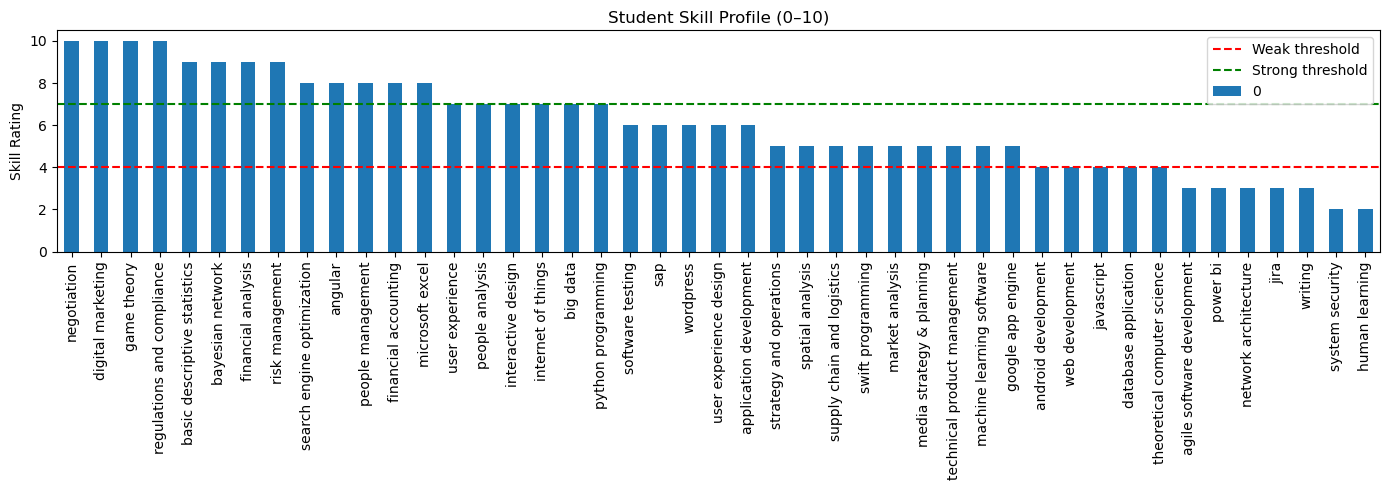

In [23]:
plt.figure(figsize=(14, 5))
student_row.sort_values(ascending=False).plot(kind="bar")
plt.axhline(WEAK_MAX, color="red", linestyle="--", label="Weak threshold")
plt.axhline(STRONG_MIN, color="green", linestyle="--", label="Strong threshold")
plt.title("Student Skill Profile (0–10)")
plt.ylabel("Skill Rating")
plt.legend()
plt.tight_layout()
plt.show()


<h4>Skill category distribution</h4>

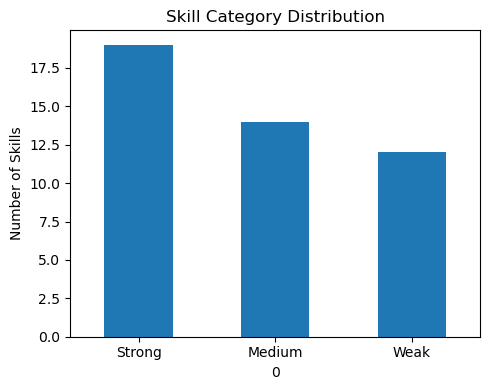

In [24]:
category_counts = skill_category.value_counts()

plt.figure(figsize=(5, 4))
category_counts.plot(kind="bar")
plt.title("Skill Category Distribution")
plt.ylabel("Number of Skills")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [25]:
WEAK_MAX = 4
STRONG_MIN = 7
ALPHA = 0.6  # weight for weak-skill improvement

In [26]:
student_raw = student_row.copy()
student_norm = student_raw / 10.0


<h4>Create skill masks</h4>

In [27]:
weak_mask = student_raw <= WEAK_MAX
strong_mask = student_raw >= STRONG_MIN

These masks ensure:

Weak logic applies ONLY to weak skills

Strong logic applies ONLY to strong skills

In [28]:
student_row = students_clean.loc[STUDENT_INDEX, SKILL_COLS]
student_norm = student_row / 10.0

weak_mask = student_row <= WEAK_MAX
strong_mask = student_row >= STRONG_MIN


In [29]:
X_rows = []

for idx, course in courses_clean.iterrows():
    row = {}

    for skill in SKILL_COLS:
        course_has_skill = course[skill]
        student_skill_norm = student_norm[skill]

        # Weak gap feature
        row[f"weak_gap_{skill}"] = (
            course_has_skill * (1 - student_skill_norm)
            if student_row[skill] <= WEAK_MAX
            else 0
        )

        # Strong match feature
        row[f"strong_match_{skill}"] = (
            course_has_skill * student_skill_norm
            if student_row[skill] >= STRONG_MIN
            else 0
        )

    X_rows.append(row)

X = pd.DataFrame(X_rows)
X.shape


(20404, 90)

1 → Top-K courses

0 → Others

In [30]:
weak_cols = [c for c in X.columns if c.startswith("weak_gap_")]
strong_cols = [c for c in X.columns if c.startswith("strong_match_")]

final_scores = (
    ALPHA * X[weak_cols].sum(axis=1) +
    (1 - ALPHA) * X[strong_cols].sum(axis=1)
)

courses_scored = courses_clean.copy()
courses_scored["final_score"] = final_scores


<h4>Choose K</h4>

In [31]:
TOP_K = 5

<h4>Label creation</h4>

In [32]:
top_k_indices = courses_scored.sort_values(
    "final_score", ascending=False
).head(TOP_K).index

y = courses_scored.index.isin(top_k_indices).astype(int)


Sanity check:

In [33]:
np.bincount(y)


array([20399,     5])

In [34]:
X_ml = X.copy()
y_ml = y.copy()

ML_DATASET = {
    "X": X_ml,
    "y": y_ml,
    "feature_names": X_ml.columns.tolist()
}

print("X shape:", X_ml.shape)
print("y shape:", y_ml.shape)


X shape: (20404, 90)
y shape: (20404,)


In [35]:
X_ml.head(2)


,weak_gap_agile software development,strong_match_agile software development,weak_gap_android development,strong_match_android development,weak_gap_angular,strong_match_angular,weak_gap_application development,strong_match_application development,weak_gap_basic descriptive statistics,strong_match_basic descriptive statistics,weak_gap_bayesian network,strong_match_bayesian network,weak_gap_big data,strong_match_big data,weak_gap_database application,strong_match_database application,weak_gap_digital marketing,strong_match_digital marketing,weak_gap_financial accounting,strong_match_financial accounting,weak_gap_financial analysis,strong_match_financial analysis,weak_gap_game theory,strong_match_game theory,weak_gap_google app engine,strong_match_google app engine,weak_gap_human learning,strong_match_human learning,weak_gap_interactive design,strong_match_interactive design,weak_gap_internet of things,strong_match_internet of things,weak_gap_javascript,strong_match_javascript,weak_gap_jira,strong_match_jira,weak_gap_machine learning software,strong_match_machine learning software,weak_gap_market analysis,strong_match_market analysis,weak_gap_media strategy & planning,strong_match_media strategy & planning,weak_gap_microsoft excel,strong_match_microsoft excel,weak_gap_negotiation,strong_match_negotiation,weak_gap_network architecture,strong_match_network architecture,weak_gap_people analysis,strong_match_people analysis,weak_gap_people management,strong_match_people management,weak_gap_power bi,strong_match_power bi,weak_gap_python programming,strong_match_python programming,weak_gap_regulations and compliance,strong_match_regulations and compliance,weak_gap_risk management,strong_match_risk management,weak_gap_sap,strong_match_sap,weak_gap_search engine optimization,strong_match_search engine optimization,weak_gap_software testing,strong_match_software testing,weak_gap_spatial analysis,strong_match_spatial analysis,weak_gap_strategy and operations,strong_match_strategy and operations,weak_gap_supply chain and logistics,strong_match_supply chain and logistics,weak_gap_swift programming,strong_match_swift programming,weak_gap_system security,strong_match_system security,weak_gap_technical product management,strong_match_technical product management,weak_gap_theoretical computer science,strong_match_theoretical computer science,weak_gap_user experience,strong_match_user experience,weak_gap_user experience design,strong_match_user experience design,weak_gap_web development,strong_match_web development,weak_gap_wordpress,strong_match_wordpress,weak_gap_writing,strong_match_writing
0,0.0,0,0.0,0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0.0,0.7,0,0,0.0,0,0.0,0.0,0,0,0.7,0,0.0,0,0.9,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0.0,0
1,0.0,0,0.0,0,0,0.0,0,0,0,0.0,0,0.0,0,0.7,0.0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0,0.0,0,0,0.0,0,0.0,0.0,0,0.0,0,0,0,0,0,0,0,0,0.8,0,0.0,0.0,0,0,0.0,0,0.0,0.0,0,0,0.0,0,0.0,0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,0,0,0,0.0,0,0,0.0,0,0,0.0,0,0,0,0.0,0


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [37]:
X = ML_DATASET["X"]
y = ML_DATASET["y"]
feature_names = ML_DATASET["feature_names"]

print("X shape:", X.shape)
print("y positives:", y.sum())


X shape: (20404, 90)
y positives: 5


Note:

- class_weight="balanced" → handle heavy imbalance

- liblinear → stable for small datasets

In [38]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    ))
])

log_reg.fit(X, y)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [39]:
coef = log_reg.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

coef_df.head(15)


,feature,coefficient
19,strong_match_financial accounting,0.708862
9,strong_match_basic descriptive statistics,0.583980
23,strong_match_game theory,0.535099
51,strong_match_people management,0.442267
57,strong_match_regulations and compliance,0.368605
88,weak_gap_writing,0.354473
43,strong_match_microsoft excel,0.333158
81,strong_match_user experience,0.269453
45,strong_match_negotiation,0.239166
32,weak_gap_javascript,0.187370


In [40]:
coef_df.tail(15)


,feature,coefficient
82,weak_gap_user experience design,0.000000
73,strong_match_swift programming,0.000000
72,weak_gap_swift programming,0.000000
77,strong_match_technical product management,0.000000
76,weak_gap_technical product management,0.000000
79,strong_match_theoretical computer science,0.000000
75,strong_match_system security,0.000000
85,strong_match_web development,0.000000
86,weak_gap_wordpress,0.000000
83,strong_match_user experience design,0.000000


In [41]:
logreg_scores = log_reg.predict_proba(X)[:, 1]

courses_scored["logreg_score"] = logreg_scores

courses_scored.sort_values(
    "logreg_score", ascending=False
).head(TOP_K)[
    ["course_title", "final_score", "logreg_score"]
]


,course_title,final_score,logreg_score
75,AI For Business,2.36,0.999867
343,Business English Communication Skills,2.26,0.999697
250,Career Success,2.10,0.999649
835,Managerial Economics and Business Analysis,2.52,0.999339
84,Business Analytics,2.04,0.999275


In [42]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)


,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
rf_scores = rf_model.predict_proba(X)[:, 1]

courses_scored["rf_score"] = rf_scores

courses_scored.sort_values(
    "rf_score", ascending=False
).head(TOP_K)[
    ["course_title", "final_score", "rf_score"]
]


,course_title,final_score,rf_score
84,Business Analytics,2.04,0.709731
75,AI For Business,2.36,0.701356
250,Career Success,2.10,0.675448
343,Business English Communication Skills,2.26,0.666144
835,Managerial Economics and Business Analysis,2.52,0.644295


In [44]:
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance.head(15)


,feature,importance
19,strong_match_financial accounting,0.153818
51,strong_match_people management,0.152950
49,strong_match_people analysis,0.110306
57,strong_match_regulations and compliance,0.097473
9,strong_match_basic descriptive statistics,0.089753
21,strong_match_financial analysis,0.077345
45,strong_match_negotiation,0.071235
26,weak_gap_human learning,0.055678
88,weak_gap_writing,0.055484
81,strong_match_user experience,0.036139


In [45]:
TRAINED_MODELS = {
    "logistic_regression": log_reg,
    "random_forest": rf_model
}


Goals: By the end of this step, we will:

- Explain global model behavior (what skills matter overall)

- Explain local decisions (why this course was recommended)

- Use SHAP correctly for each model type

- Produce clear, report-ready plots

- Tie explanations back to student weak/strong skills

In [46]:
# !pip install shap

In [47]:
import shap

In [48]:
X = ML_DATASET["X"]
y = ML_DATASET["y"]
feature_names = ML_DATASET["feature_names"]

log_reg = TRAINED_MODELS["logistic_regression"]
rf_model = TRAINED_MODELS["random_forest"]


<h4>Create explainer</h4>

In [49]:
X_scaled = log_reg.named_steps["scaler"].transform(X)
clf = log_reg.named_steps["clf"]

explainer_lr = shap.LinearExplainer(
    clf,
    X_scaled,
    feature_names=feature_names
)


<h4>Compute SHAP values</h4>

In [50]:
shap_values_lr = explainer_lr.shap_values(X_scaled)

Shape sanity check

In [51]:
np.array(shap_values_lr).shape

(20404, 90)

<h4>Global summary plot (LogReg)</h4>

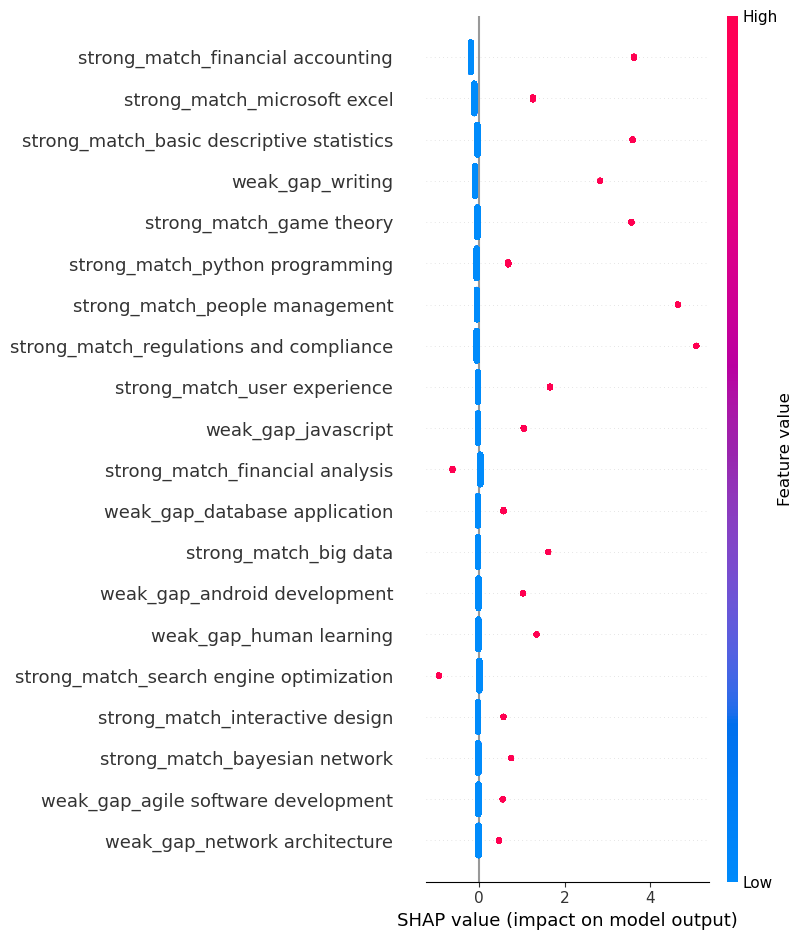

In [52]:
shap.summary_plot(
    shap_values_lr,
    X_scaled,
    feature_names=feature_names,
    show=True
)


<h4>Create TreeExplainer</h4>

In [53]:
explainer_rf = shap.TreeExplainer(rf_model)


<h4>Compute SHAP values</h4>

In [54]:
shap_values_rf = explainer_rf.shap_values(X)
print("type:", type(shap_values_rf))
print("shape:", np.array(shap_values_rf).shape)


type: <class 'numpy.ndarray'>
shape: (20404, 90, 2)


In [55]:
shap_values_rf_pos = shap_values_rf[:, :, 1]

print("X shape:", X.shape)
print("shap_values_rf_pos shape:", shap_values_rf_pos.shape)


X shape: (20404, 90)
shap_values_rf_pos shape: (20404, 90)


<h4>Global summary plot (Tree model)</h4>

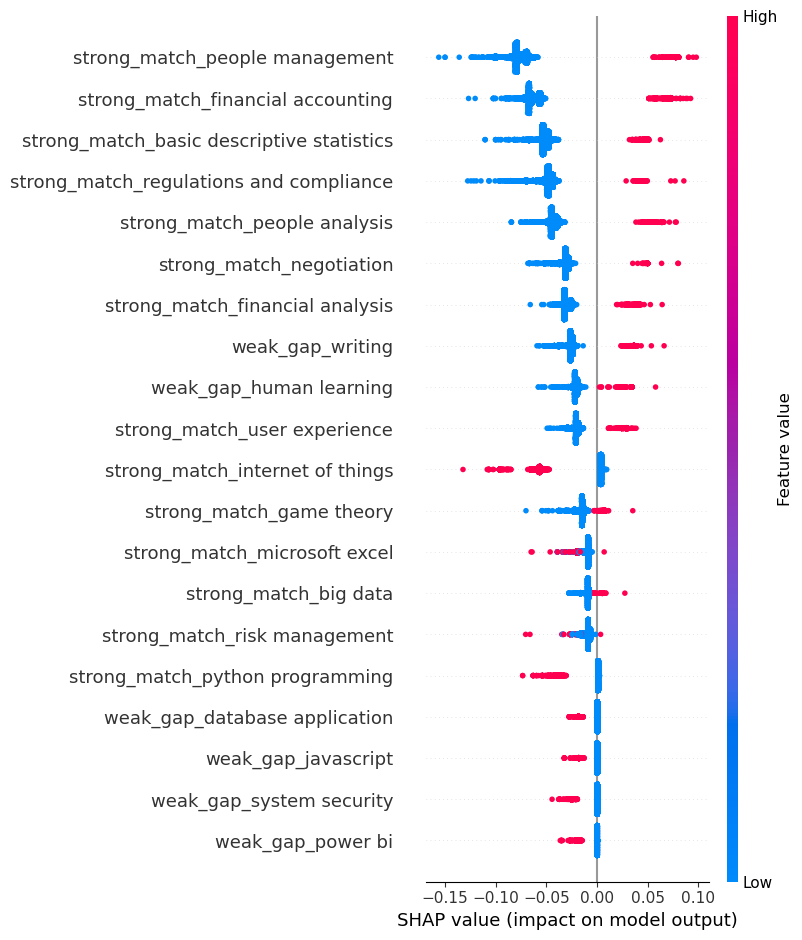

In [56]:
shap.summary_plot(
    shap_values_rf_pos,
    X,
    feature_names=feature_names,
    show=True
)


<h4>Pick top recommended course</h4>

In [57]:
top_course_idx = courses_scored.sort_values(
    "rf_score", ascending=False
).index[0]

top_course_idx


np.int64(84)

In [58]:
#Extract its feature row:
x_instance = X.loc[top_course_idx]


<h4>SHAP waterfall plot (tree model)</h4>

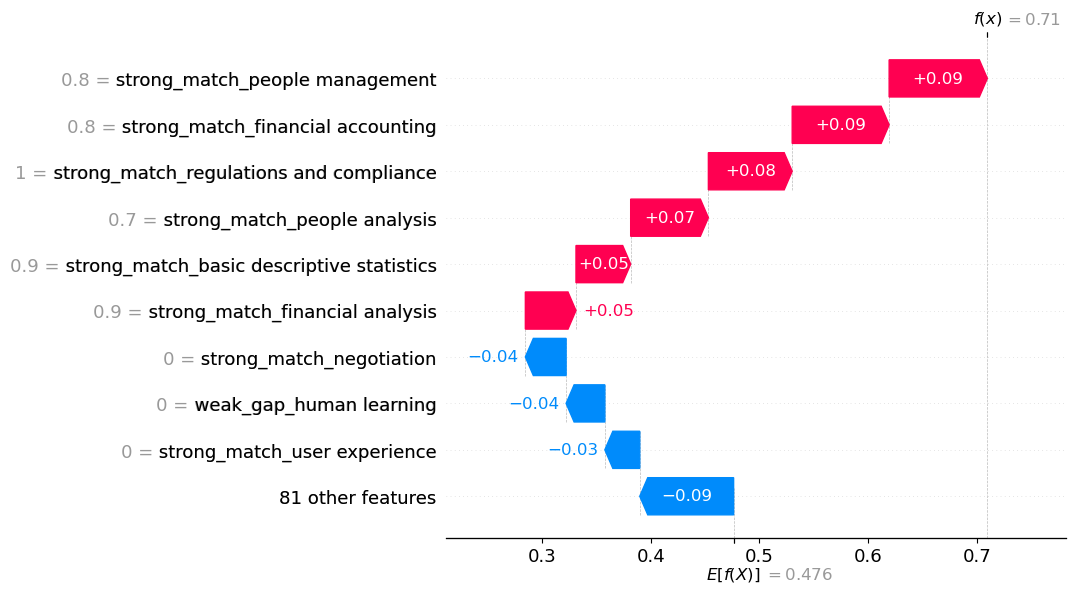

In [59]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_rf_pos[top_course_idx],
        base_values=explainer_rf.expected_value[1],
        data=x_instance,
        feature_names=feature_names
    )
)

This plot explains:

Which skills pushed the decision up

Which skills pushed it down

Final recommendation probability

In [60]:
shap_contrib = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values_rf_pos[top_course_idx]
}).sort_values("shap_value", ascending=False)

shap_contrib.head(10)


,feature,shap_value
51,strong_match_people management,0.090348
19,strong_match_financial accounting,0.089192
57,strong_match_regulations and compliance,0.077114
49,strong_match_people analysis,0.071475
9,strong_match_basic descriptive statistics,0.050314
21,strong_match_financial analysis,0.046587
31,strong_match_internet of things,0.009478
55,strong_match_python programming,0.002448
14,weak_gap_database application,0.000817
32,weak_gap_javascript,0.000654


<h4>convert to natural language</h4>

In [61]:
def explain_feature(feature):
    if feature.startswith("weak_gap_"):
        return f"Improves weak skill: {feature.replace('weak_gap_', '')}"
    if feature.startswith("strong_match_"):
        return f"Enhances strong skill: {feature.replace('strong_match_', '')}"
    return feature

shap_contrib["explanation"] = shap_contrib["feature"].apply(explain_feature)

shap_contrib.head(10)[["feature", "shap_value", "explanation"]]


,feature,shap_value,explanation
51,strong_match_people management,0.090348,Enhances strong skill: people management
19,strong_match_financial accounting,0.089192,Enhances strong skill: financial accounting
57,strong_match_regulations and compliance,0.077114,Enhances strong skill: regulations and compliance
49,strong_match_people analysis,0.071475,Enhances strong skill: people analysis
9,strong_match_basic descriptive statistics,0.050314,Enhances strong skill: basic descriptive stati...
21,strong_match_financial analysis,0.046587,Enhances strong skill: financial analysis
31,strong_match_internet of things,0.009478,Enhances strong skill: internet of things
55,strong_match_python programming,0.002448,Enhances strong skill: python programming
14,weak_gap_database application,0.000817,Improves weak skill: database application
32,weak_gap_javascript,0.000654,Improves weak skill: javascript


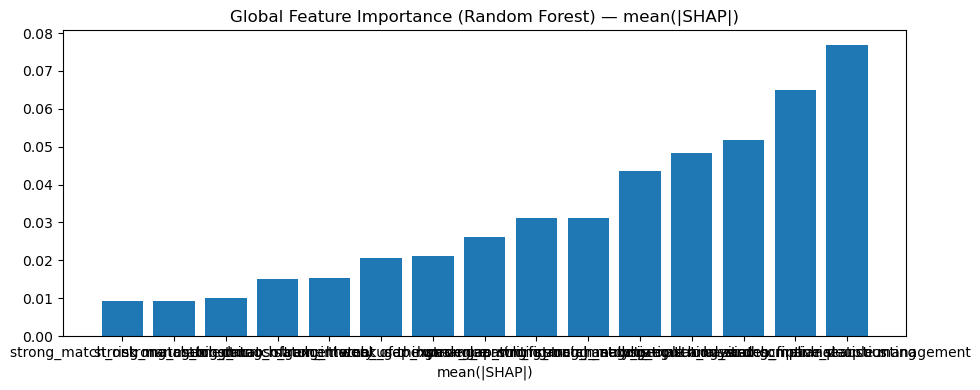

,feature,mean_abs_shap
51,strong_match_people management,0.076875
19,strong_match_financial accounting,0.065000
9,strong_match_basic descriptive statistics,0.051865
57,strong_match_regulations and compliance,0.048390
49,strong_match_people analysis,0.043475
45,strong_match_negotiation,0.031248
21,strong_match_financial analysis,0.031215
88,weak_gap_writing,0.026080
26,weak_gap_human learning,0.021182
81,strong_match_user experience,0.020533


In [62]:
# Global importance: mean(|SHAP|)
global_importance = np.abs(shap_values_rf_pos).mean(axis=0)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": global_importance
}).sort_values("mean_abs_shap", ascending=False).head(15)

plt.figure(figsize=(10,4))
plt.bar(imp_df["feature"][::-1], imp_df["mean_abs_shap"][::-1])
plt.title("Global Feature Importance (Random Forest) — mean(|SHAP|)")
plt.xlabel("mean(|SHAP|)")
plt.tight_layout()
plt.show()

imp_df


In [63]:
TOP_K = 5
top_labels = courses_scored.sort_values("rf_score", ascending=False).head(TOP_K).index.tolist()

explanations_top5 = []

for lbl in top_labels:
    pos = X.index.get_loc(lbl)
    contrib = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values_rf_pos[pos]
    }).sort_values("shap_value", ascending=False).head(6)

    contrib["reason"] = contrib["feature"].apply(explain_feature)

    explanations_top5.append({
        "course_title": courses_scored.loc[lbl, "course_title"],
        "top_reasons": "; ".join([f"{r} ({v:.3f})" for r, v in zip(contrib["reason"], contrib["shap_value"])])
    })

pd.DataFrame(explanations_top5)


,course_title,top_reasons
0,Business Analytics,Enhances strong skill: people management (0.09...
1,AI For Business,Enhances strong skill: financial accounting (0...
2,Career Success,Enhances strong skill: people management (0.09...
3,Business English Communication Skills,Enhances strong skill: people management (0.09...
4,Managerial Economics and Business Analysis,Enhances strong skill: financial accounting (0...


Goals: By the end of this step, we will:

- Generate a local explanation for the top recommended course

- Show the top contributing features

- Convert features into human-readable reasons

- Do it for Top-5

### Quick checkpoint

In [64]:
courses=courses_clean
students=students_clean
print("Courses:", courses.shape)
print("Students:", students.shape)
print("Skills:", len(SKILL_COLS))
print("First 5 skills:", SKILL_COLS[:5])


Courses: (20404, 53)
Students: (108, 46)
Skills: 45
First 5 skills: ['agile software development', 'android development', 'angular', 'application development', 'basic descriptive statistics']


## **02 Student Skill Profile**

### Imports

In [65]:
from pathlib import Path


### Rebuild SKILL_COLS safely

In [66]:
# Skills are columns that are 0/1 in courses and numeric in students
course_skill_cols = [c for c in courses.columns if courses[c].dropna().isin([0,1]).all()]
student_numeric_cols = [c for c in students.columns if pd.api.types.is_numeric_dtype(students[c])]

SKILL_COLS = sorted(list(set(course_skill_cols).intersection(student_numeric_cols)))
assert len(SKILL_COLS) == 45


### Create student id column

In [67]:
NON_SKILL_STUDENT_COLS = [c for c in students.columns if c not in SKILL_COLS]
print("Non-skill student cols:", NON_SKILL_STUDENT_COLS)


Non-skill student cols: ['Timestamp']


In [68]:
# If there is a real id column, use it; otherwise create one
if len(NON_SKILL_STUDENT_COLS) >= 1:
    STUDENT_ID_COL = NON_SKILL_STUDENT_COLS[0]  # usually the only one
else:
    STUDENT_ID_COL = "student_id"
    students[STUDENT_ID_COL] = np.arange(len(students))

print("Using STUDENT_ID_COL =", STUDENT_ID_COL)
students[[STUDENT_ID_COL]].head()


Using STUDENT_ID_COL = Timestamp


,Timestamp
0,11/26/2025 13:58:11
1,11/26/2025 14:02:25
2,11/26/2025 14:03:51
3,11/26/2025 14:08:38
4,11/26/2025 14:09:54


### Define thresholds + compute normalized ratings

In [69]:
WEAK_MAX = 4
STRONG_MIN = 7

students_skills = students[SKILL_COLS].copy()
students_norm = students_skills / 10.0  # 0..1


### Compute weak/strong masks for ALL students (vectorized)

In [70]:
weak_mask   = students_skills.le(WEAK_MAX)     # (n_students, 45) boolean
strong_mask = students_skills.ge(STRONG_MIN)   # (n_students, 45) boolean

print("weak_mask shape:", weak_mask.shape)
print("strong_mask shape:", strong_mask.shape)


weak_mask shape: (108, 45)
strong_mask shape: (108, 45)


### Create a simple “profile summary” table (for sanity checking)

In [71]:
profile_summary = pd.DataFrame({
    STUDENT_ID_COL: students[STUDENT_ID_COL],
    "num_weak": weak_mask.sum(axis=1),
    "num_strong": strong_mask.sum(axis=1),
    "avg_skill": students_skills.mean(axis=1).round(2)
}).sort_values("num_weak", ascending=False)

profile_summary.head(10)


,Timestamp,num_weak,num_strong,avg_skill
3,11/26/2025 14:08:38,45,0,1.00
89,12/1/2025 0:00:49,45,0,1.18
34,11/28/2025 8:21:24,44,1,1.16
57,11/30/2025 22:32:25,41,4,1.98
52,11/30/2025 22:07:56,41,0,1.91
72,11/30/2025 23:30:36,41,3,2.04
107,12/1/2025 18:59:19,41,0,1.98
77,11/30/2025 23:44:47,41,3,2.20
62,11/30/2025 22:43:20,40,3,2.31
106,12/1/2025 18:41:25,40,1,1.64


#### show one student’s top weak/strong skills

In [72]:
def top_skills_for_student(i, k=8):
    row = students_skills.iloc[i]
    weakest = row.sort_values().head(k)
    strongest = row.sort_values(ascending=False).head(k)
    return weakest, strongest

weakest, strongest = top_skills_for_student(0, k=8)
print("Weakest:\n", weakest)
print("\nStrongest:\n", strongest)


Weakest:
 human learning                2.0
system security               2.0
network architecture          3.0
agile software development    3.0
power bi                      3.0
jira                          3.0
writing                       3.0
javascript                    4.0
Name: 0, dtype: float64

Strongest:
 digital marketing               10.0
game theory                     10.0
regulations and compliance      10.0
negotiation                     10.0
financial analysis               9.0
bayesian network                 9.0
risk management                  9.0
basic descriptive statistics     9.0
Name: 0, dtype: float64


### Quick checkpoint

In [73]:
print("Students:", students.shape)
print("Student id col:", STUDENT_ID_COL)
print("Avg num_weak:", profile_summary["num_weak"].mean())
print("Avg num_strong:", profile_summary["num_strong"].mean())
profile_summary.head(5)


Students: (108, 46)
Student id col: Timestamp
Avg num_weak: 18.5
Avg num_strong: 15.703703703703704


,Timestamp,num_weak,num_strong,avg_skill
3,11/26/2025 14:08:38,45,0,1.00
89,12/1/2025 0:00:49,45,0,1.18
34,11/28/2025 8:21:24,44,1,1.16
57,11/30/2025 22:32:25,41,4,1.98
52,11/30/2025 22:07:56,41,0,1.91


## **03 Rule Based Scoring**

### Define the hybrid scoring logic

Scoring formula:
score =

Σ over weak skills:   course_has_skill × (1 − normalized_student_skill)

Σ over strong skills: course_has_skill × normalized_student_skill


This:

- Pushes courses that fix weaknesses

- Still rewards matching strengths

- Fully SHAP/LIME friendly later

### Vectorized scoring

In [74]:
# Courses skill matrix: (n_courses, 45)
C = courses[SKILL_COLS].values.astype(float)

scores_per_student = []

for i in range(len(students)):
    student_id = students.loc[i, STUDENT_ID_COL]

    s_norm   = students_norm.iloc[i].values          # (45,)
    s_weak   = weak_mask.iloc[i].values               # bool (45,)
    s_strong = strong_mask.iloc[i].values             # bool (45,)

    # Weak contribution
    weak_contrib = C[:, s_weak] @ (1 - s_norm[s_weak]) if s_weak.any() else 0

    # Strong contribution
    strong_contrib = C[:, s_strong] @ (s_norm[s_strong]) if s_strong.any() else 0

    total_score = weak_contrib + strong_contrib

    df = pd.DataFrame({
        "student_id": student_id,
        "course_index": np.arange(len(courses)),
        "score": total_score
    })

    scores_per_student.append(df)

scores_df = pd.concat(scores_per_student, ignore_index=True)

scores_df.head()


,student_id,course_index,score
0,11/26/2025 13:58:11,0,2.3
1,11/26/2025 13:58:11,1,1.5
2,11/26/2025 13:58:11,2,2.4
3,11/26/2025 13:58:11,3,3.1
4,11/26/2025 13:58:11,4,1.5


### Attach course metadata (for recommendations)

In [75]:
COURSE_META_COLS = [c for c in courses.columns if c not in SKILL_COLS]

scores_df = scores_df.merge(
    courses[COURSE_META_COLS].reset_index().rename(columns={"index": "course_index"}),
    on="course_index",
    how="left"
)


### Get Top-5 recommendations per student

In [76]:
TOP_K = 5

topk_recs = (
    scores_df
    .sort_values(["student_id", "score"], ascending=[True, False])
    .groupby("student_id")
    .head(TOP_K)
    .reset_index(drop=True)
)

topk_recs.head(10)


,student_id,course_index,score,course_title,rating,review_count,skills_list,platform,level,duration,skills_text
0,11/26/2025 13:58:11,835,6.3,Managerial Economics and Business Analysis,4.8,3800.0,"['securities sales', 'investment management', ...",coursera,1,78.21,securities sales | investment management | ris...
1,11/26/2025 13:58:11,75,5.5,AI For Business,4.7,400.0,"['user experience', 'big data', 'artificial ne...",coursera,1,78.21,user experience | big data | artificial neural...
2,11/26/2025 13:58:11,84,5.1,Business Analytics,4.6,17700.0,"['people development', 'operations research', ...",coursera,1,78.21,people development | operations research | tal...
3,11/26/2025 13:58:11,250,4.9,Career Success,4.6,41300.0,"['people development', 'data visualization sof...",coursera,1,78.21,people development | data visualization softwa...
4,11/26/2025 13:58:11,343,4.9,Business English Communication Skills,4.8,4400.0,"['negotiation', 'public relations', 'visualiza...",coursera,2,78.21,negotiation | public relations | visualization...
5,11/26/2025 14:02:25,835,7.1,Managerial Economics and Business Analysis,4.8,3800.0,"['securities sales', 'investment management', ...",coursera,1,78.21,securities sales | investment management | ris...
6,11/26/2025 14:02:25,84,5.3,Business Analytics,4.6,17700.0,"['people development', 'operations research', ...",coursera,1,78.21,people development | operations research | tal...
7,11/26/2025 14:02:25,280,5.2,Introduction to Business,4.7,242.0,"['accounting', 'storytelling', 'strategy and o...",coursera,1,34.76,accounting | storytelling | strategy and opera...
8,11/26/2025 14:02:25,6240,5.1,QGIS and Google Earth Engine Python API for Sp...,4.1,95.0,"['spatial data analysis', 'spatial analysis', ...",udemy,0,3.50,spatial data analysis | spatial analysis | big...
9,11/26/2025 14:02:25,3,4.8,Google Digital Marketing & E-commerce,4.8,21400.0,"['social media', 'media strategy & planning', ...",coursera,1,78.21,social media | media strategy & planning | web...


#### Sanity check one student:

In [77]:
sid = topk_recs["student_id"].iloc[0]
topk_recs[topk_recs["student_id"] == sid][
    ["student_id", "score"] + COURSE_META_COLS[:3]
]


,student_id,score,course_title,rating,review_count
0,11/26/2025 13:58:11,6.3,Managerial Economics and Business Analysis,4.8,3800.0
1,11/26/2025 13:58:11,5.5,AI For Business,4.7,400.0
2,11/26/2025 13:58:11,5.1,Business Analytics,4.6,17700.0
3,11/26/2025 13:58:11,4.9,Career Success,4.6,41300.0
4,11/26/2025 13:58:11,4.9,Business English Communication Skills,4.8,4400.0


### Quick checkpoint

In [78]:
print("Scores DF shape:", scores_df.shape)
print("Top-5 rows:", topk_recs.shape)
topk_recs.groupby("student_id").size().value_counts()


Scores DF shape: (2203632, 11)
Top-5 rows: (540, 11)


5    108
Name: count, dtype: int64

## **04 Training Pair Generation**

### Split STUDENTS → train / test (80 / 20)

In [79]:
from sklearn.model_selection import train_test_split

unique_students = students[STUDENT_ID_COL].unique()

train_students, test_students = train_test_split(
    unique_students,
    test_size=0.2,
    random_state=42
)

print("Train students:", len(train_students))
print("Test students:", len(test_students))


Train students: 86
Test students: 22


In [80]:
assert set(train_students).isdisjoint(set(test_students))


### Split rule-based results by student

In [81]:
scores_train = scores_df[scores_df["student_id"].isin(train_students)]
scores_test  = scores_df[scores_df["student_id"].isin(test_students)]

topk_df=topk_recs
topk_train = topk_df[topk_df["student_id"].isin(train_students)]
topk_test  = topk_df[topk_df["student_id"].isin(test_students)]

print("scores_train:", scores_train.shape)
print("scores_test:", scores_test.shape)


scores_train: (1754744, 11)
scores_test: (448888, 11)


### Generate labels (pseudo-labels)

Rules:

- y = 1 → course in student’s top-5

- y = 0 → sampled negatives (important!)

In [82]:
topk_train["label"] = 1

C:\Users\habee\AppData\Local\Temp\ipykernel_18416\3144199522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topk_train["label"] = 1


### Negative sampling

If we keep all negatives → dataset explodes.

Rule of thumb: 5 positives → 10–20 negatives

We’ll do 10 negatives per student.

In [83]:
NEG_PER_STUDENT = 10

negatives = []

for sid in train_students:
    student_scores = scores_train[scores_train["student_id"] == sid]
    pos_courses = topk_train[topk_train["student_id"] == sid]["course_index"]

    neg_pool = student_scores[
        ~student_scores["course_index"].isin(pos_courses)
    ]

    sampled = neg_pool.sample(
        n=min(NEG_PER_STUDENT, len(neg_pool)),
        random_state=42
    ).copy()

    sampled["label"] = 0
    negatives.append(sampled)

negatives_df = pd.concat(negatives, ignore_index=True)

train_pairs = pd.concat([topk_train, negatives_df], ignore_index=True)

print("Training pairs:", train_pairs.shape)
train_pairs["label"].value_counts()


Training pairs: (1290, 12)


label
0    860
1    430
Name: count, dtype: int64

### Build SHAP/LIME-friendly feature vectors

Each feature is interpretable:

- weak_gap_<skill>

- strong_match_<skill>

#### Feature construction

In [84]:
X_rows = []

for _, row in train_pairs.iterrows():
    sid = row["student_id"]
    cidx = int(row["course_index"])

    s_idx = students[students[STUDENT_ID_COL] == sid].index[0]

    s_norm   = students_norm.iloc[s_idx]
    s_weak   = weak_mask.iloc[s_idx]
    s_strong = strong_mask.iloc[s_idx]
    course   = courses.loc[cidx, SKILL_COLS]

    features = {}

    for skill in SKILL_COLS:
        if s_weak[skill]:
            features[f"weak_gap_{skill}"] = course[skill] * (1 - s_norm[skill])
        else:
            features[f"weak_gap_{skill}"] = 0.0

        if s_strong[skill]:
            features[f"strong_match_{skill}"] = course[skill] * s_norm[skill]
        else:
            features[f"strong_match_{skill}"] = 0.0

    features["label"] = row["label"]
    X_rows.append(features)

train_ml_df = pd.DataFrame(X_rows)

print("ML training shape:", train_ml_df.shape)
train_ml_df.head(2)


ML training shape: (1290, 91)


,weak_gap_agile software development,strong_match_agile software development,weak_gap_android development,strong_match_android development,weak_gap_angular,strong_match_angular,weak_gap_application development,strong_match_application development,weak_gap_basic descriptive statistics,strong_match_basic descriptive statistics,weak_gap_bayesian network,strong_match_bayesian network,weak_gap_big data,strong_match_big data,weak_gap_database application,strong_match_database application,weak_gap_digital marketing,strong_match_digital marketing,weak_gap_financial accounting,strong_match_financial accounting,weak_gap_financial analysis,strong_match_financial analysis,weak_gap_game theory,strong_match_game theory,weak_gap_google app engine,strong_match_google app engine,weak_gap_human learning,strong_match_human learning,weak_gap_interactive design,strong_match_interactive design,weak_gap_internet of things,strong_match_internet of things,weak_gap_javascript,strong_match_javascript,weak_gap_jira,strong_match_jira,weak_gap_machine learning software,strong_match_machine learning software,weak_gap_market analysis,strong_match_market analysis,weak_gap_media strategy & planning,strong_match_media strategy & planning,weak_gap_microsoft excel,strong_match_microsoft excel,weak_gap_negotiation,strong_match_negotiation,weak_gap_network architecture,strong_match_network architecture,weak_gap_people analysis,strong_match_people analysis,weak_gap_people management,strong_match_people management,weak_gap_power bi,strong_match_power bi,weak_gap_python programming,strong_match_python programming,weak_gap_regulations and compliance,strong_match_regulations and compliance,weak_gap_risk management,strong_match_risk management,weak_gap_sap,strong_match_sap,weak_gap_search engine optimization,strong_match_search engine optimization,weak_gap_software testing,strong_match_software testing,weak_gap_spatial analysis,strong_match_spatial analysis,weak_gap_strategy and operations,strong_match_strategy and operations,weak_gap_supply chain and logistics,strong_match_supply chain and logistics,weak_gap_swift programming,strong_match_swift programming,weak_gap_system security,strong_match_system security,weak_gap_technical product management,strong_match_technical product management,weak_gap_theoretical computer science,strong_match_theoretical computer science,weak_gap_user experience,strong_match_user experience,weak_gap_user experience design,strong_match_user experience design,weak_gap_web development,strong_match_web development,weak_gap_wordpress,strong_match_wordpress,weak_gap_writing,strong_match_writing,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.8,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.7,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Quick checkpoint

In [85]:
train_ml_df["label"].value_counts(), train_ml_df.shape


(label
 0    860
 1    430
 Name: count, dtype: int64,
 (1290, 91))

## **05 Model Training**

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [87]:
train_ml_df.head(2)


,weak_gap_agile software development,strong_match_agile software development,weak_gap_android development,strong_match_android development,weak_gap_angular,strong_match_angular,weak_gap_application development,strong_match_application development,weak_gap_basic descriptive statistics,strong_match_basic descriptive statistics,weak_gap_bayesian network,strong_match_bayesian network,weak_gap_big data,strong_match_big data,weak_gap_database application,strong_match_database application,weak_gap_digital marketing,strong_match_digital marketing,weak_gap_financial accounting,strong_match_financial accounting,weak_gap_financial analysis,strong_match_financial analysis,weak_gap_game theory,strong_match_game theory,weak_gap_google app engine,strong_match_google app engine,weak_gap_human learning,strong_match_human learning,weak_gap_interactive design,strong_match_interactive design,weak_gap_internet of things,strong_match_internet of things,weak_gap_javascript,strong_match_javascript,weak_gap_jira,strong_match_jira,weak_gap_machine learning software,strong_match_machine learning software,weak_gap_market analysis,strong_match_market analysis,weak_gap_media strategy & planning,strong_match_media strategy & planning,weak_gap_microsoft excel,strong_match_microsoft excel,weak_gap_negotiation,strong_match_negotiation,weak_gap_network architecture,strong_match_network architecture,weak_gap_people analysis,strong_match_people analysis,weak_gap_people management,strong_match_people management,weak_gap_power bi,strong_match_power bi,weak_gap_python programming,strong_match_python programming,weak_gap_regulations and compliance,strong_match_regulations and compliance,weak_gap_risk management,strong_match_risk management,weak_gap_sap,strong_match_sap,weak_gap_search engine optimization,strong_match_search engine optimization,weak_gap_software testing,strong_match_software testing,weak_gap_spatial analysis,strong_match_spatial analysis,weak_gap_strategy and operations,strong_match_strategy and operations,weak_gap_supply chain and logistics,strong_match_supply chain and logistics,weak_gap_swift programming,strong_match_swift programming,weak_gap_system security,strong_match_system security,weak_gap_technical product management,strong_match_technical product management,weak_gap_theoretical computer science,strong_match_theoretical computer science,weak_gap_user experience,strong_match_user experience,weak_gap_user experience design,strong_match_user experience design,weak_gap_web development,strong_match_web development,weak_gap_wordpress,strong_match_wordpress,weak_gap_writing,strong_match_writing,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.8,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.7,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.7,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


### Separate features / label

In [88]:
X_train = train_ml_df.drop(columns=["label"])
y_train = train_ml_df["label"]

print("X_train:", X_train.shape)
print("y_train:", y_train.value_counts())


X_train: (1290, 90)
y_train: label
0    860
1    430
Name: count, dtype: int64


### **Logistic Regression (baseline model)**

Why Logistic Regression first?

- Linear

- Stable

- SHAP-friendly

#### Pipeline (scaling + model)

In [89]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])
logreg_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Quick training performance (sanity check)

In [90]:
train_preds = logreg_pipeline.predict(X_train)
train_probs = logreg_pipeline.predict_proba(X_train)[:, 1]

print(classification_report(y_train, train_preds))
print("Train ROC-AUC:", roc_auc_score(y_train, train_probs))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       860
           1       1.00      0.99      0.99       430

    accuracy                           1.00      1290
   macro avg       1.00      0.99      1.00      1290
weighted avg       1.00      1.00      1.00      1290

Train ROC-AUC: 0.9966468361276366


### Prepare TEST SET

#### Build TEST pairs

In [91]:
#Positives
topk_test = topk_df[topk_df["student_id"].isin(test_students)].copy()
topk_test["label"] = 1

#Negatives
NEG_PER_STUDENT = 10
negatives_test = []

for sid in test_students:
    student_scores = scores_df[scores_df["student_id"] == sid]
    pos_courses = topk_test[topk_test["student_id"] == sid]["course_index"]

    neg_pool = student_scores[
        ~student_scores["course_index"].isin(pos_courses)
    ]

    sampled = neg_pool.sample(
        n=min(NEG_PER_STUDENT, len(neg_pool)),
        random_state=42
    ).copy()

    sampled["label"] = 0
    negatives_test.append(sampled)

test_pairs = pd.concat([topk_test] + negatives_test, ignore_index=True)
print("Test pairs:", test_pairs.shape)


Test pairs: (330, 12)


### Build TEST feature matrix

In [92]:
X_test_rows = []

for _, row in test_pairs.iterrows():
    sid = row["student_id"]
    cidx = int(row["course_index"])

    s_idx = students[students[STUDENT_ID_COL] == sid].index[0]

    s_norm   = students_norm.iloc[s_idx]
    s_weak   = weak_mask.iloc[s_idx]
    s_strong = strong_mask.iloc[s_idx]
    course   = courses.loc[cidx, SKILL_COLS]

    features = {}

    for skill in SKILL_COLS:
        features[f"weak_gap_{skill}"] = (
            course[skill] * (1 - s_norm[skill]) if s_weak[skill] else 0.0
        )
        features[f"strong_match_{skill}"] = (
            course[skill] * s_norm[skill] if s_strong[skill] else 0.0
        )

    features["label"] = row["label"]
    X_test_rows.append(features)

test_ml_df = pd.DataFrame(X_test_rows)

X_test = test_ml_df.drop(columns=["label"])
y_test = test_ml_df["label"]

print("X_test:", X_test.shape)
y_test.value_counts()


X_test: (330, 90)


label
0    220
1    110
Name: count, dtype: int64

### Final evaluation

In [93]:
test_preds = logreg_pipeline.predict(X_test)
test_probs = logreg_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, test_preds))
print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       220
           1       1.00      1.00      1.00       110

    accuracy                           1.00       330
   macro avg       1.00      1.00      1.00       330
weighted avg       1.00      1.00      1.00       330

Test ROC-AUC: 1.0


### Save trained model

In [94]:
import os
import joblib
from datetime import datetime

joblib.dump(logreg_pipeline, "../output/Model/logistic_regression.pkl")

print("Model saved.")


Model saved.


### **Tree Model — Random Forest**

In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,          # keeps it interpretable
    min_samples_leaf=5,   # avoids memorization
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluate on TEST set

In [97]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, rf_preds))
print("RF Test ROC-AUC:", roc_auc_score(y_test, rf_probs))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98       220
           1       1.00      0.91      0.95       110

    accuracy                           0.97       330
   macro avg       0.98      0.95      0.97       330
weighted avg       0.97      0.97      0.97       330

RF Test ROC-AUC: 1.0


### Feature importance

In [98]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(15)


strong_match_user experience               0.103056
weak_gap_financial accounting              0.079447
strong_match_web development               0.068038
weak_gap_big data                          0.057763
strong_match_search engine optimization    0.050725
weak_gap_financial analysis                0.048235
strong_match_financial accounting          0.044465
weak_gap_market analysis                   0.036234
weak_gap_search engine optimization        0.033536
strong_match_application development       0.029990
weak_gap_application development           0.026966
strong_match_big data                      0.026546
strong_match_financial analysis            0.025484
strong_match_market analysis               0.024018
weak_gap_web development                   0.023344
dtype: float64

### Save the tree model

In [99]:
joblib.dump(rf_model, "../output/Model/random_forest.pkl")

print("Model saved.")

Model saved.


### Save The skill columns 

In [100]:
import json, os
os.makedirs("../output/Model", exist_ok=True)
with open("../output/Model/skill_cols.json", "w", encoding="utf-8") as f:
    json.dump(SKILL_COLS, f, ensure_ascii=False, indent=2)


### x_background to build explainers

In [101]:
X_train = train_ml_df.drop(columns=["label"])

bg = X_train.sample(n=min(500, len(X_train)), random_state=42)
bg.to_csv("../output/Model/x_background.csv", index=False)


## **06 Shap Explanations**

In [102]:
# !pip -q install shap
import shap


### feature engineering function

In [103]:
FEATURE_COLS = [f"weak_gap_{s}" for s in SKILL_COLS] + [f"strong_match_{s}" for s in SKILL_COLS]

def build_features_for_pair(student_id: str, course_index: int) -> pd.Series:
    # locate student row
    s_idx = students.index[students[STUDENT_ID_COL] == student_id][0]
    
    s_norm   = students_norm.iloc[s_idx]
    s_weak   = weak_mask.iloc[s_idx]
    s_strong = strong_mask.iloc[s_idx]
    course   = courses.loc[course_index, SKILL_COLS]

    feats = {}

    for skill in SKILL_COLS:
        feats[f"weak_gap_{skill}"] = course[skill] * (1 - s_norm[skill]) if s_weak[skill] else 0.0
        feats[f"strong_match_{skill}"] = course[skill] * s_norm[skill] if s_strong[skill] else 0.0

    return pd.Series(feats)

def build_feature_matrix(student_id: str, course_indices: list[int]) -> pd.DataFrame:
    rows = [build_features_for_pair(student_id, cidx) for cidx in course_indices]
    X = pd.DataFrame(rows)
    # enforce column order
    return X[FEATURE_COLS]


### Choose one TEST student + candidate courses to explain

We’ll explain top-5 recommendations for an unseen student, plus a few negatives for contrast.

In [104]:
# pick a test student
sid = test_students[0]
print("Chosen test student:", sid)

# teacher top-5 for this student (from rule-based)
top5 = (topk_df[topk_df["student_id"] == sid]
        .sort_values("score", ascending=False)
        .head(5))
top5_indices = top5["course_index"].astype(int).tolist()
print("Top5 course indices:", top5_indices)

# sample some "non-recommended" courses for contrast (optional but useful)
pool = scores_df[scores_df["student_id"] == sid].sort_values("score", ascending=False)

neg_sample = (pool[~pool["course_index"].isin(top5_indices)]
              .sample(n=5, random_state=42)["course_index"]
              .astype(int).tolist())

candidate_indices = top5_indices + neg_sample
X_candidate = build_feature_matrix(sid, candidate_indices)

print("Candidate X shape:", X_candidate.shape)


Chosen test student: 11/30/2025 23:44:47
Top5 course indices: [835, 158, 84, 73, 250]
Candidate X shape: (10, 90)


In [105]:
#metadata so the tables are human-readable
cmeta = courses.loc[candidate_indices, COURSE_META_COLS].reset_index(drop=True)
display(pd.concat([pd.Series(candidate_indices, name="course_index"), cmeta], axis=1).head(10))


,course_index,course_title,rating,review_count,skills_list,platform,level,duration,skills_text
0,835,Managerial Economics and Business Analysis,4.8,3800.0,"['securities sales', 'investment management', ...",coursera,1,78.21,securities sales | investment management | ris...
1,158,Search Engine Optimization (SEO),4.6,12100.0,"['user experience', 'social media', 'influenci...",coursera,1,78.21,user experience | social media | influencing |...
2,84,Business Analytics,4.6,17700.0,"['people development', 'operations research', ...",coursera,1,78.21,people development | operations research | tal...
3,73,Meta Android Developer,4.6,5100.0,"['user experience', 'mobile development', 'pro...",coursera,1,78.21,user experience | mobile development | program...
4,250,Career Success,4.6,41300.0,"['people development', 'data visualization sof...",coursera,1,78.21,people development | data visualization softwa...
5,3498,Building Web Applications with Go - Intermedia...,4.6,365.0,"['database application', 'application developm...",udemy,2,18.50,database application | application development
6,17441,Microsoft Project 2016 For Beginners: Master t...,4.5,368.0,['internet of things'],udemy,1,9.50,internet of things
7,7776,"How to Make Video Games: The Smarter, Faster Way",4.6,54.0,"['user experience design', 'user experience']",udemy,1,19.00,user experience design | user experience
8,20099,A Unique Foot Reflexology Massage Certificate ...,4.9,355.0,"['cloud clients', 'c programming language fami...",udemy,0,3.50,cloud clients | c programming language family
9,18759,Leadership Complete Guide - Succeed in Management,4.8,321.0,"['leadership development', 'leadership and man...",udemy,0,3.50,leadership development | leadership and manage...


### **PART A — SHAP for Logistic Regression (pipeline)**

In [106]:
train_feature_order = logreg_pipeline.feature_names_in_

# Candidate features aligned to training order
X_c = X_candidate[train_feature_order]

# Background set: use a sample of your training X (recommended for SHAP)
X_bg = X_ml[train_feature_order].sample(
    n=min(200, len(X_ml)), random_state=42
)

# ----- Scale using the pipeline's scaler -----
scaler = logreg_pipeline.named_steps["scaler"] 
X_bg_scaled = scaler.transform(X_bg)
X_c_scaled  = scaler.transform(X_c)


# Make scaled dataframes WITH feature names
X_bg_scaled_df = pd.DataFrame(X_bg_scaled, columns=train_feature_order)
X_c_scaled_df  = pd.DataFrame(X_c_scaled,  columns=train_feature_order)

In [107]:
explainer_lr = shap.LinearExplainer(clf, X_bg_scaled_df, feature_perturbation="interventional")
shap_vals_lr = explainer_lr(X_c_scaled_df)

C:\Users\habee\anaconda3\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


#### 4A) Global view (on the candidates)

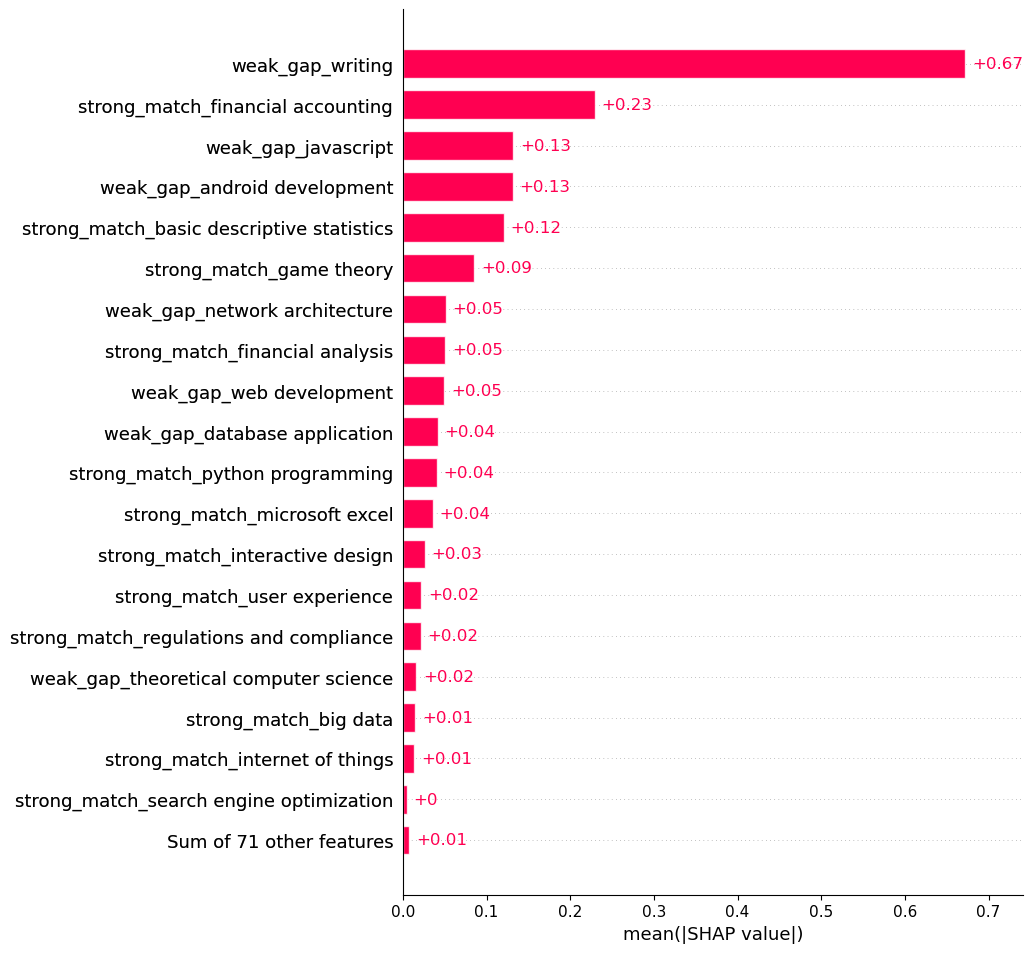

In [108]:
shap.plots.bar(shap_vals_lr, max_display=20)


#### Local explanation for each recommended course (waterfall)

Recommended course_index: 835


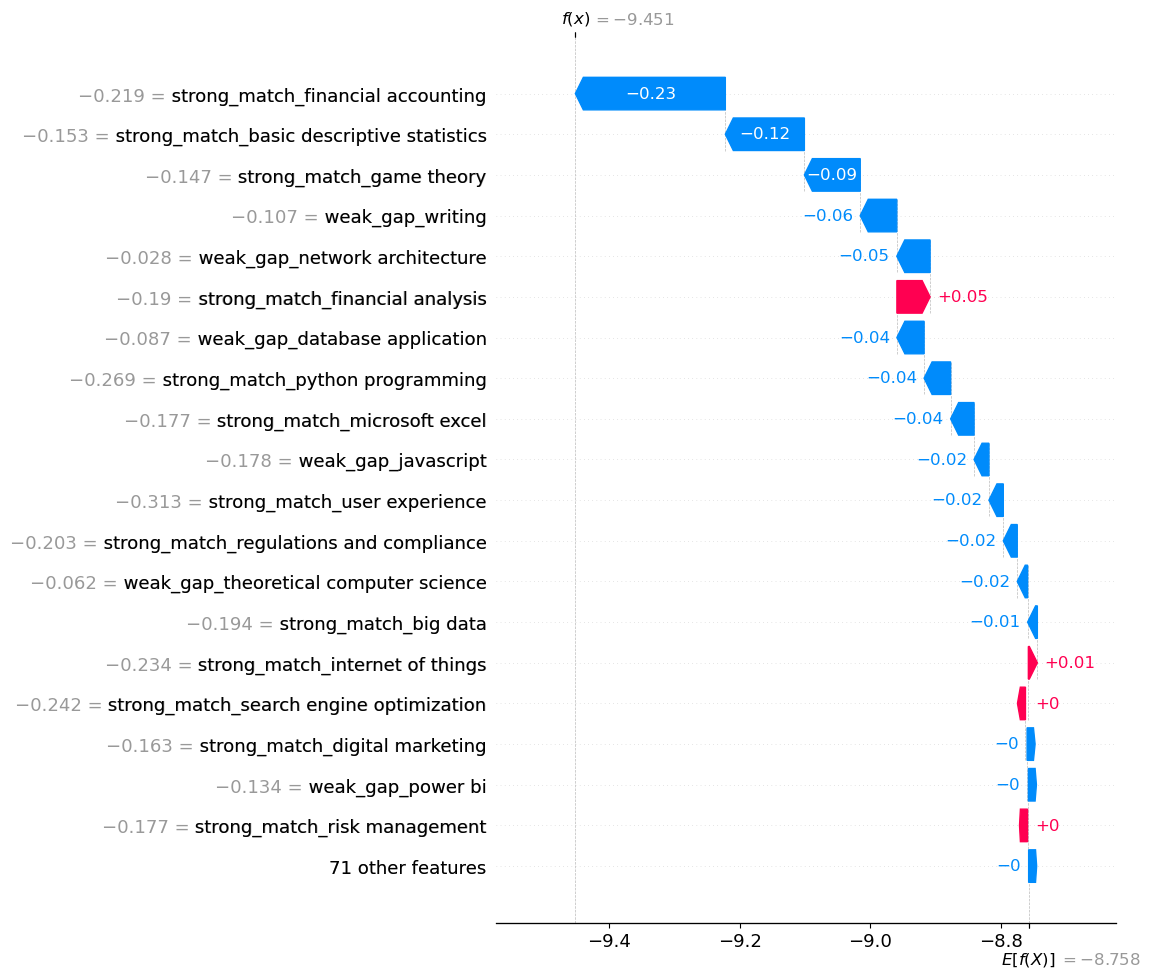

Recommended course_index: 158


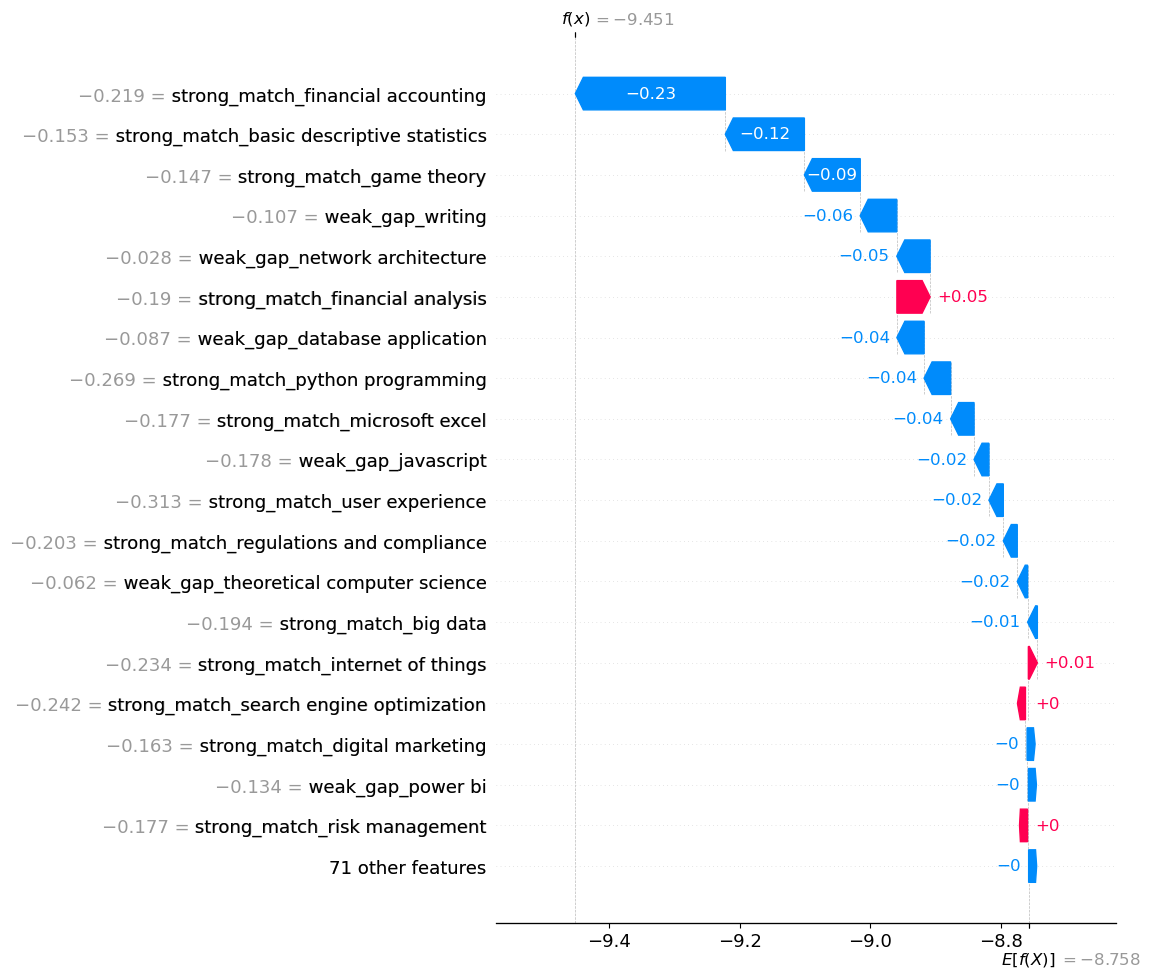

Recommended course_index: 84


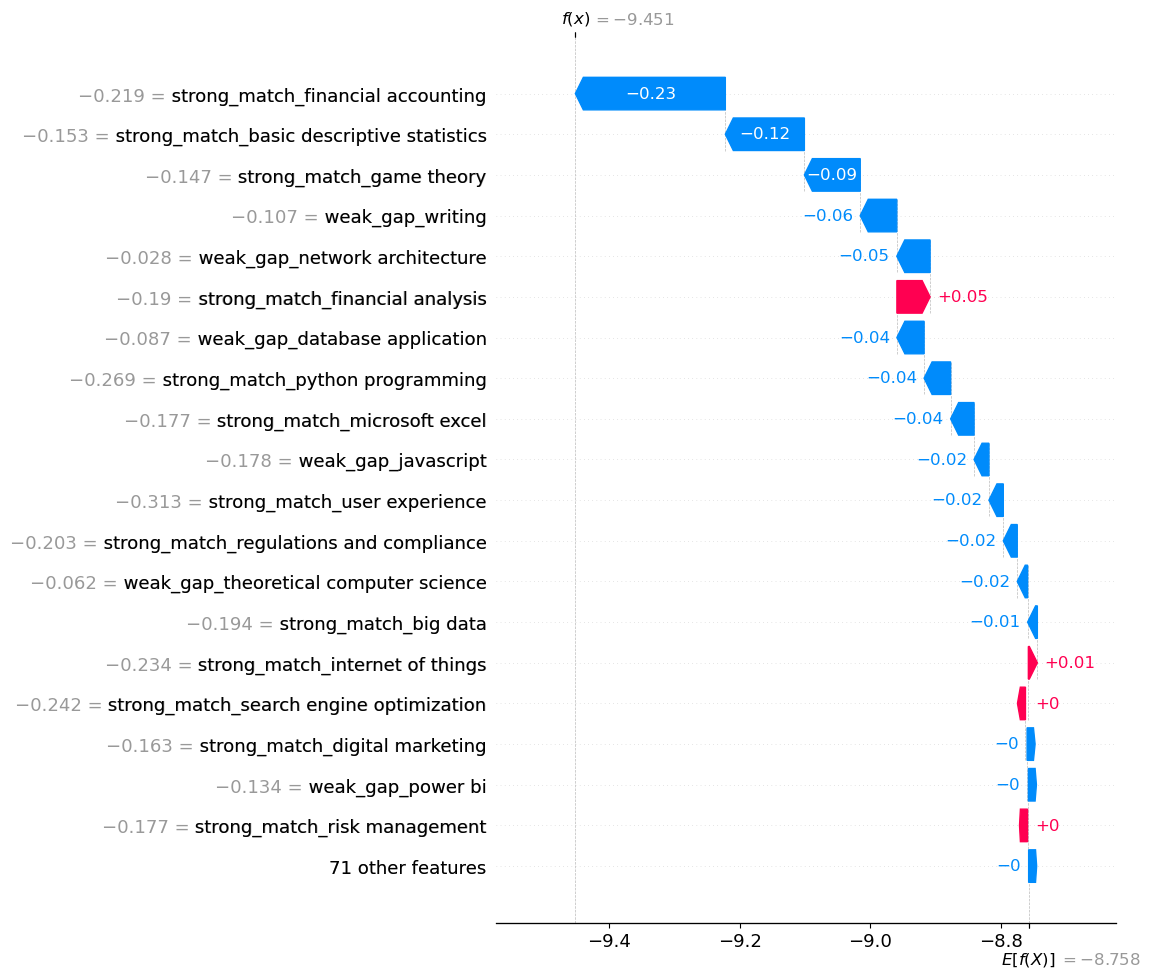

Recommended course_index: 73


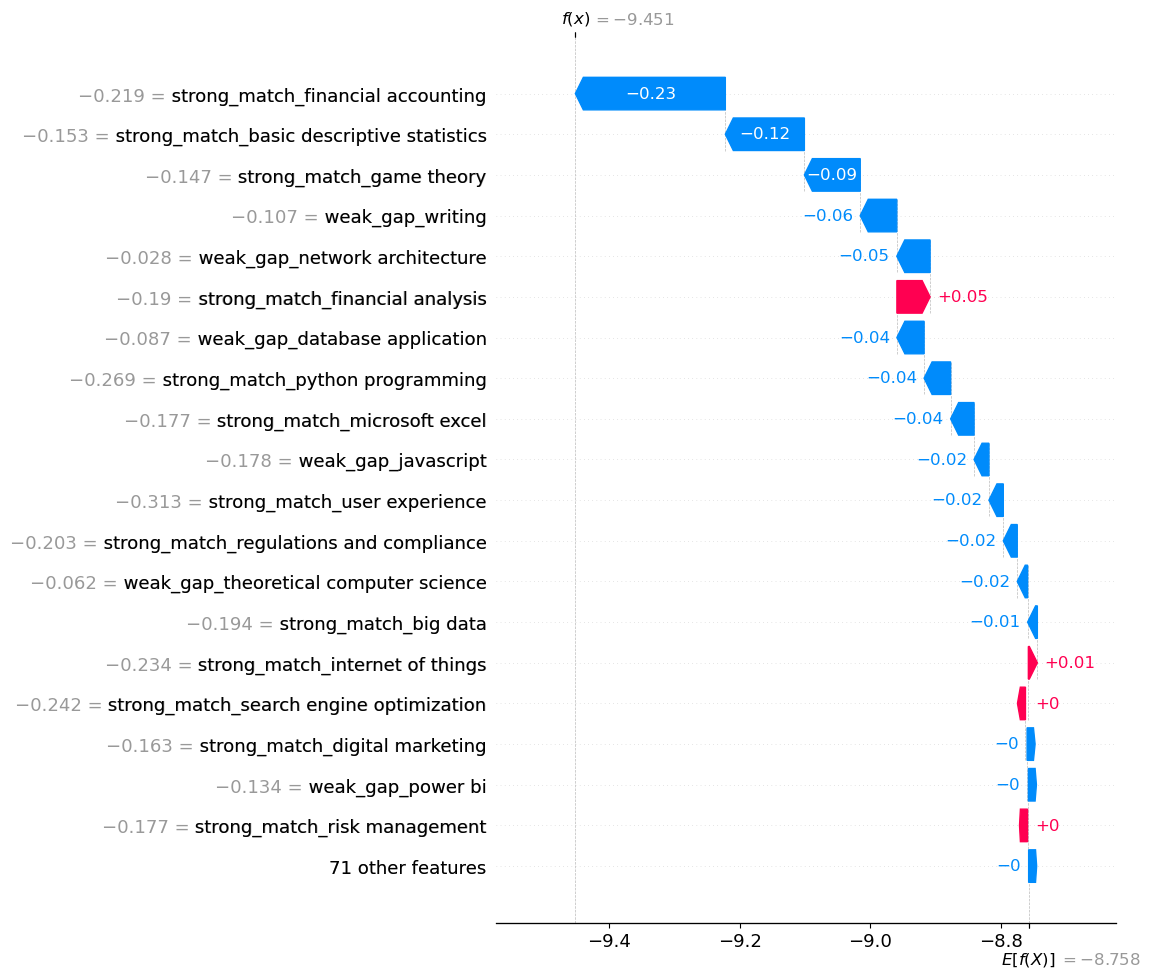

Recommended course_index: 250


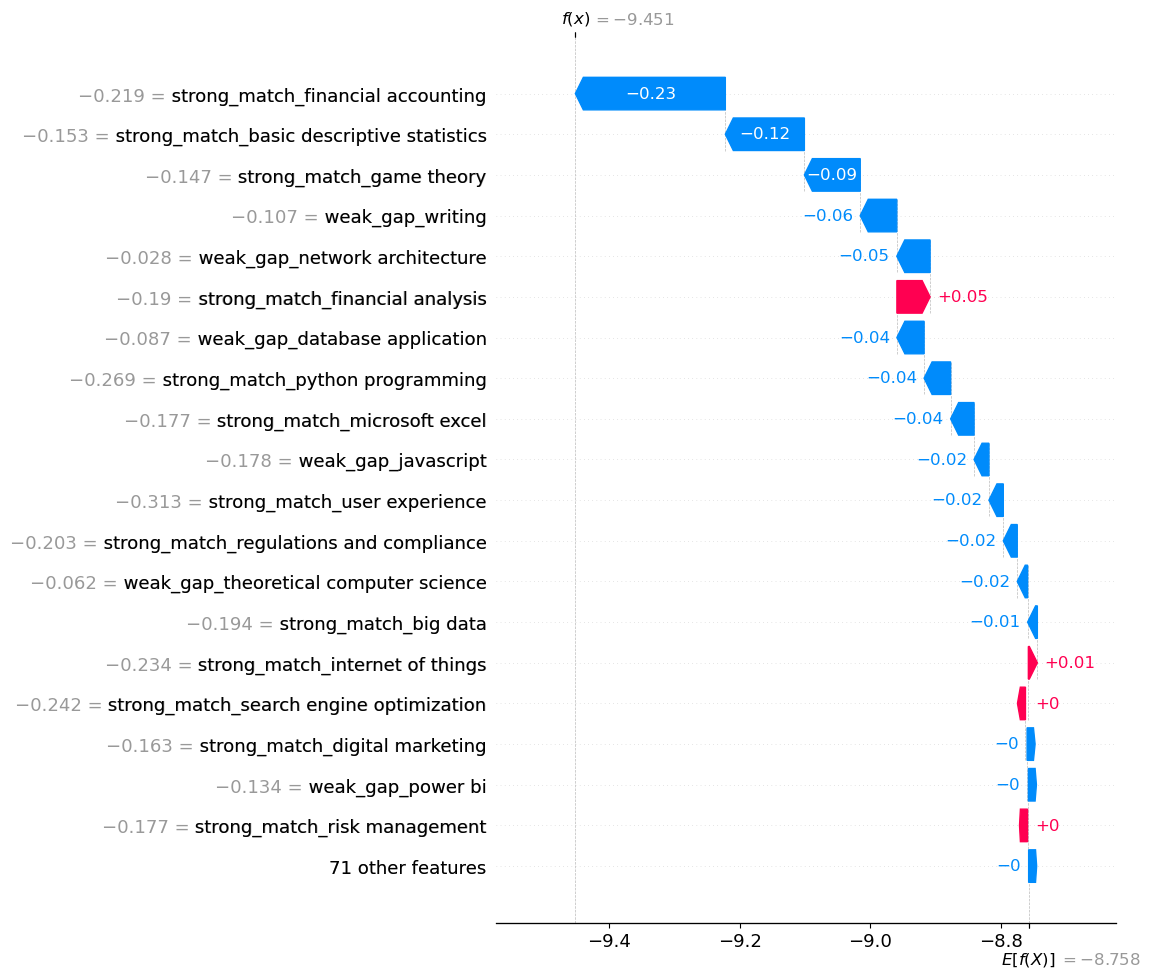

In [109]:
for i in range(5):
    print("Recommended course_index:", candidate_indices[i])
    shap.plots.waterfall(shap_vals_lr[0], max_display=20)


### **PART B — SHAP for Random Forest (TreeSHAP)**

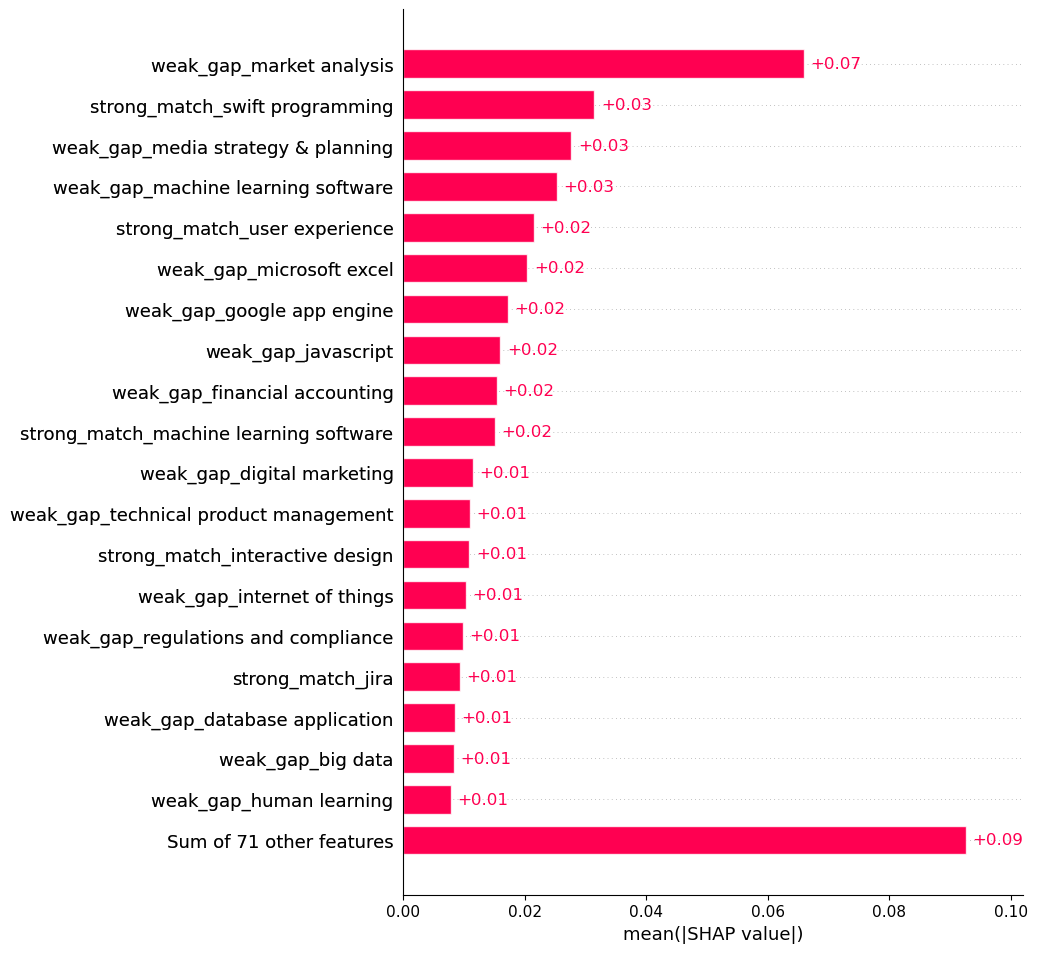

In [110]:
explainer_rf = shap.TreeExplainer(rf_model)
sv = explainer_rf.shap_values(X_candidate)

# sv can be list [class0, class1]
if isinstance(sv, list):
    sv1 = sv[1]
    base = explainer_rf.expected_value[1]
else:
    # sometimes sv is array (n_samples, n_features, n_classes)
    sv1 = sv[:, :, 1]
    base = explainer_rf.expected_value[1] if isinstance(explainer_rf.expected_value, (list, np.ndarray)) else explainer_rf.expected_value

shap_vals_rf_pos = shap.Explanation(
    values=sv1,
    base_values=np.repeat(base, sv1.shape[0]),
    data=X_candidate.values,
    feature_names=X_candidate.columns
)

shap.plots.bar(shap_vals_rf_pos, max_display=20)


Recommended course_index: 835


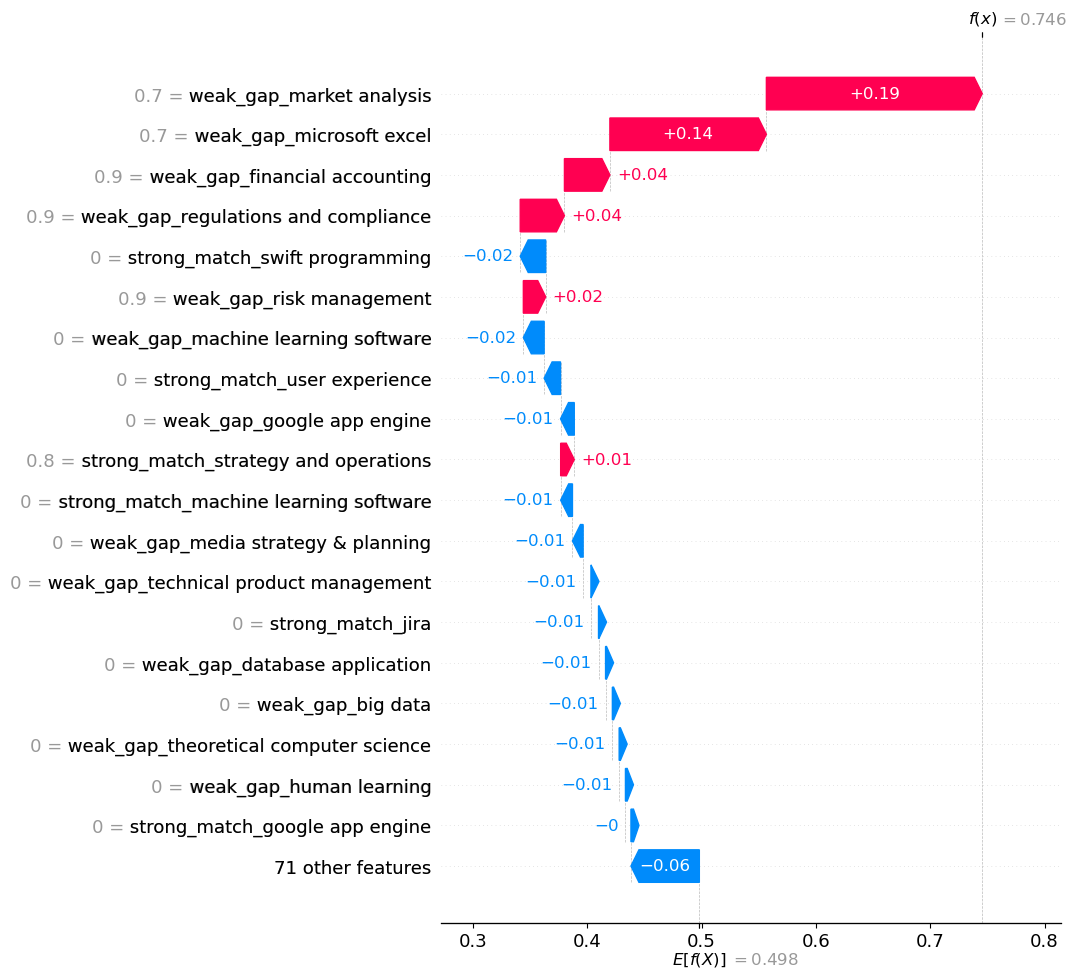

Recommended course_index: 158


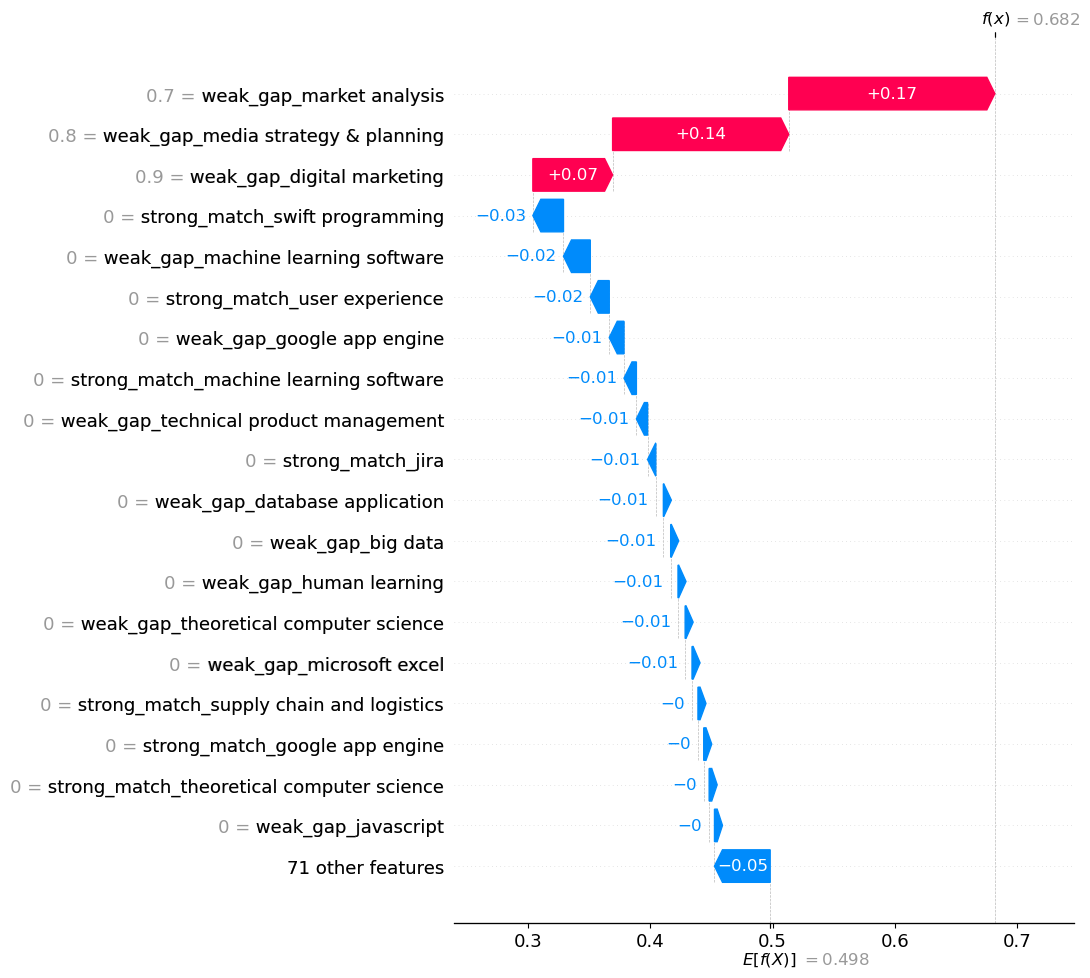

Recommended course_index: 84


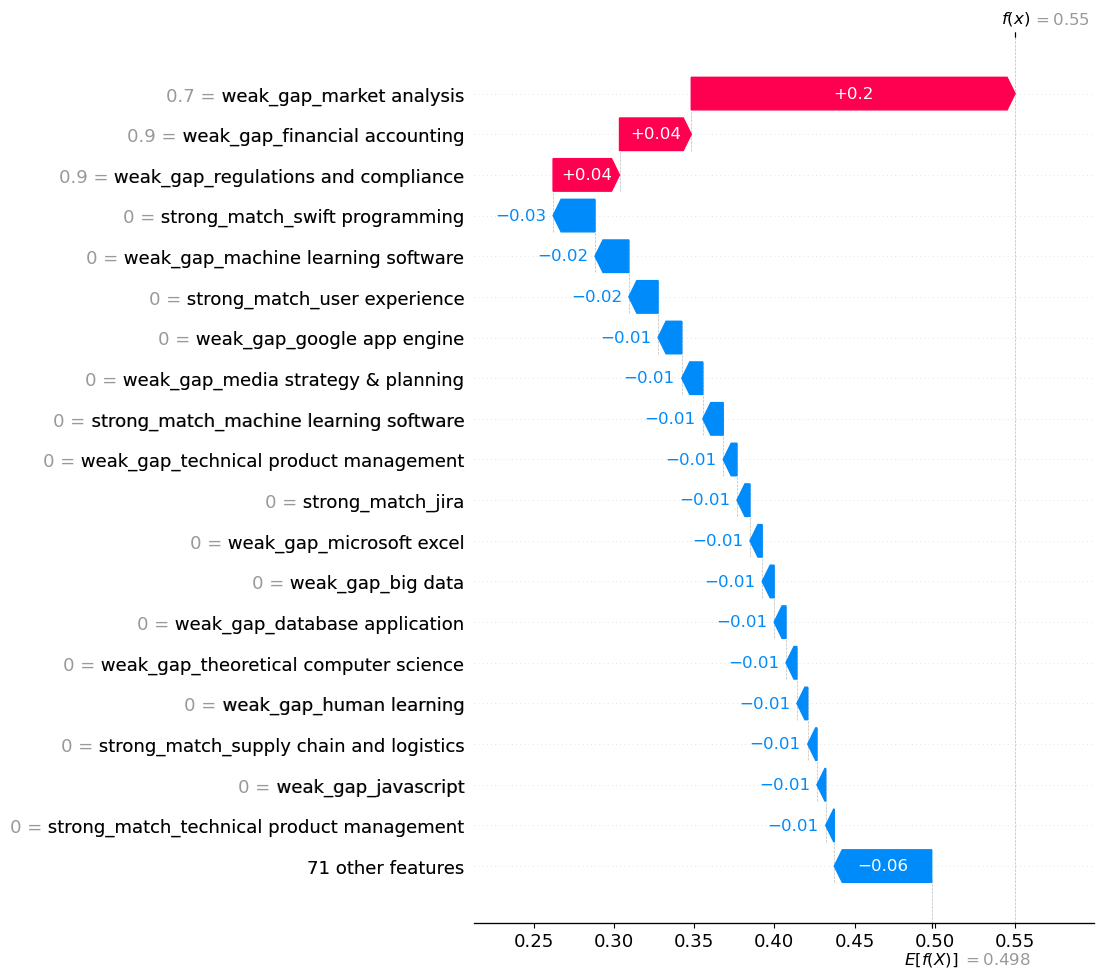

Recommended course_index: 73


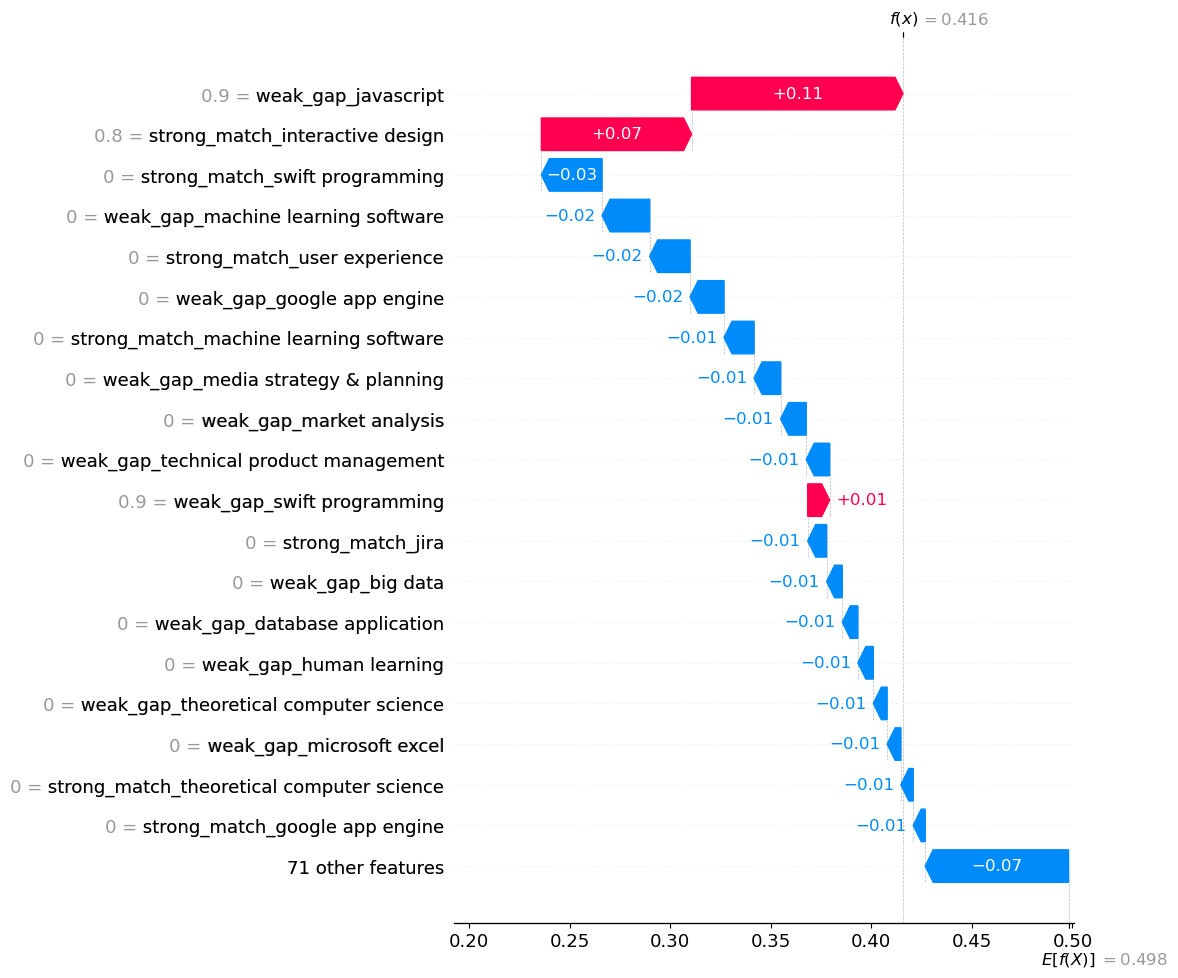

Recommended course_index: 250


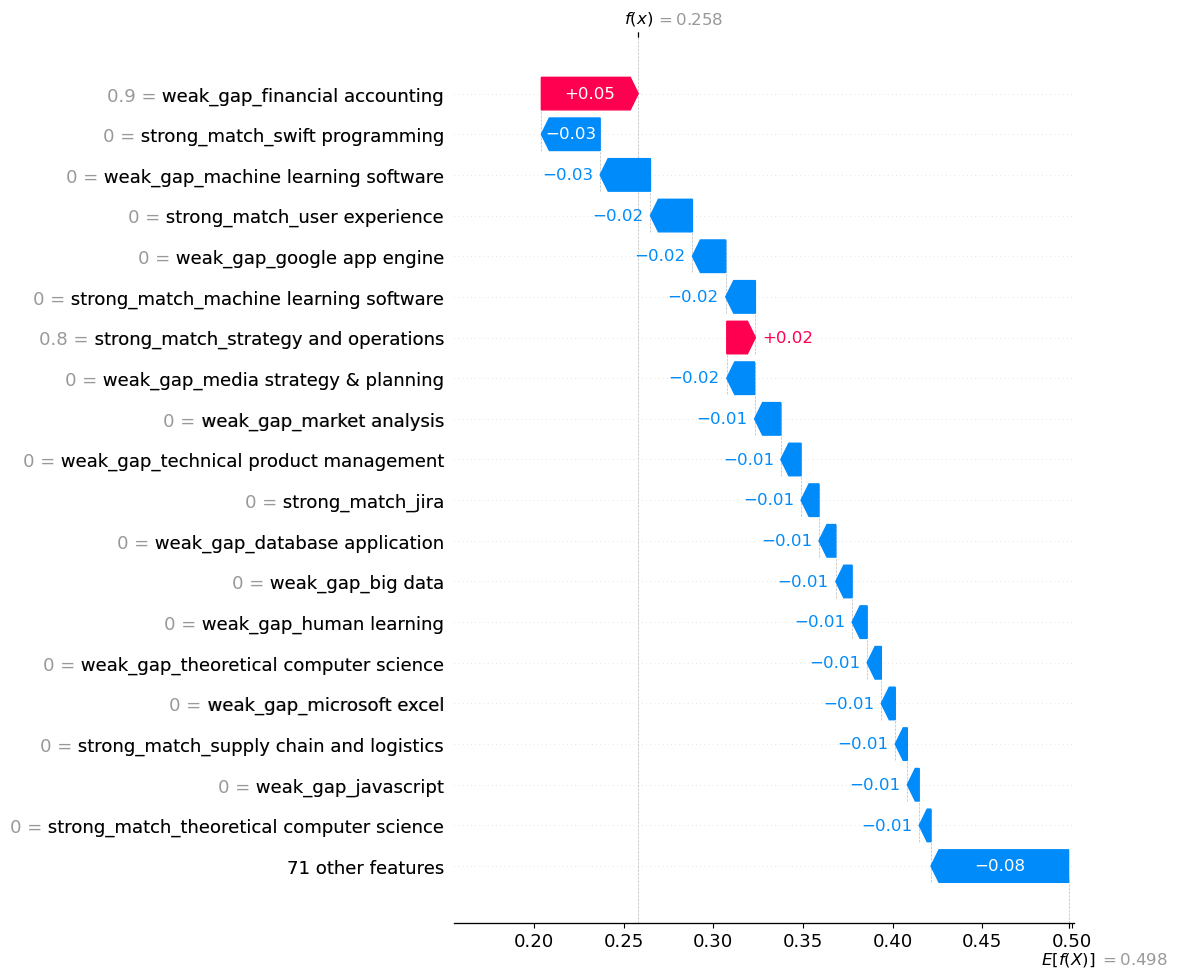

In [111]:
for i in range(5):
    print("Recommended course_index:", candidate_indices[i])
    shap.plots.waterfall(shap_vals_rf_pos[i], max_display=20)


### Convert SHAP feature contributions → Skill-level explanation

Right now SHAP shows features like:

- weak_gap_python

- strong_match_python

So we aggregate:

skill_contribution = shap(weak_gap_skill) + shap(strong_match_skill)

In [112]:
def shap_to_skill_table(shap_values_row, feature_names) -> pd.DataFrame:
    # shap_values_row: (n_features,)
    s = pd.Series(shap_values_row, index=feature_names)

    skill_scores = {}
    for skill in SKILL_COLS:
        skill_scores[skill] = s.get(f"weak_gap_{skill}", 0.0) + s.get(f"strong_match_{skill}", 0.0)

    out = (pd.Series(skill_scores)
             .sort_values(ascending=False)
             .reset_index())
    out.columns = ["skill", "shap_contribution"]
    out["abs_contribution"] = out["shap_contribution"].abs()
    return out


#### Skill-level table for Logistic Regression (top-1 recommendation)

In [113]:
# top-1 recommendation is candidate row 0
lr_skill_table = shap_to_skill_table(shap_vals_lr[0].values, X_candidate.columns)
lr_skill_table.head(15)


,skill,shap_contribution,abs_contribution
0,microsoft excel,5.077851e-02,5.077851e-02
1,search engine optimization,1.374536e-02,1.374536e-02
2,machine learning software,4.437683e-03,4.437683e-03
3,big data,1.595799e-16,1.595799e-16
4,power bi,2.023827e-17,2.023827e-17
5,theoretical computer science,1.006316e-17,1.006316e-17
6,angular,5.720899e-18,5.720899e-18
7,people analysis,0.000000e+00,0.000000e+00
8,negotiation,0.000000e+00,0.000000e+00
9,javascript,0.000000e+00,0.000000e+00


#### Skill-level table for Random Forest (top-1 recommendation)

In [114]:
rf_skill_table = shap_to_skill_table(shap_vals_rf_pos[0].values, X_candidate.columns)
rf_skill_table.head(15)


,skill,shap_contribution,abs_contribution
0,market analysis,1.886888e-01,1.886888e-01
1,microsoft excel,1.359746e-01,1.359746e-01
2,financial accounting,3.975967e-02,3.975967e-02
3,regulations and compliance,3.866620e-02,3.866620e-02
4,risk management,1.936876e-02,1.936876e-02
5,strategy and operations,1.189135e-02,1.189135e-02
6,android development,0.000000e+00,0.000000e+00
7,web development,0.000000e+00,0.000000e+00
8,agile software development,-1.827305e-07,1.827305e-07
9,user experience design,-2.036882e-05,2.036882e-05


### Quick checkpoint

In [115]:
train_feature_order = logreg_pipeline.feature_names_in_

# Reindex enforces same columns + same order.
# If anything is missing, you'll see NaNs (or you can fill with 0)
X_candidate_aligned = X_candidate.reindex(columns=train_feature_order, fill_value=0.0)

print("LogReg candidate probs:", logreg_pipeline.predict_proba(X_candidate_aligned)[:5, 1])
print("RF candidate probs:", rf_model.predict_proba(X_candidate_aligned)[:5, 1])
print("Top LR skills:\n", lr_skill_table.head(10))


LogReg candidate probs: [0.99992069 0.99857413 0.99996271 0.99880677 0.99894868]
RF candidate probs: [0.96990507 0.8885809  0.97893744 0.86228693 0.83680835]
Top LR skills:
                           skill  shap_contribution  abs_contribution
0               microsoft excel       5.077851e-02      5.077851e-02
1    search engine optimization       1.374536e-02      1.374536e-02
2     machine learning software       4.437683e-03      4.437683e-03
3                      big data       1.595799e-16      1.595799e-16
4                      power bi       2.023827e-17      2.023827e-17
5  theoretical computer science       1.006316e-17      1.006316e-17
6                       angular       5.720899e-18      5.720899e-18
7               people analysis       0.000000e+00      0.000000e+00
8                   negotiation       0.000000e+00      0.000000e+00
9                    javascript       0.000000e+00      0.000000e+00


## **07 Lime Explanations**

In [116]:
from lime.lime_tabular import LimeTabularExplainer

### Feature builder

In [117]:
FEATURE_COLS = [f"weak_gap_{s}" for s in SKILL_COLS] + [f"strong_match_{s}" for s in SKILL_COLS]

def build_features_for_pair(student_id: str, course_index: int) -> pd.Series:
    s_idx = students.index[students[STUDENT_ID_COL] == student_id][0]
    
    s_norm   = students_norm.iloc[s_idx]
    s_weak   = weak_mask.iloc[s_idx]
    s_strong = strong_mask.iloc[s_idx]
    course   = courses.loc[course_index, SKILL_COLS]

    feats = {}
    for skill in SKILL_COLS:
        feats[f"weak_gap_{skill}"] = course[skill] * (1 - s_norm[skill]) if s_weak[skill] else 0.0
        feats[f"strong_match_{skill}"] = course[skill] * s_norm[skill] if s_strong[skill] else 0.0

    return pd.Series(feats)

def build_feature_matrix(student_id: str, course_indices: list[int]) -> pd.DataFrame:
    X = pd.DataFrame([build_features_for_pair(student_id, cidx) for cidx in course_indices])
    return X[FEATURE_COLS]


### Pick one student + one recommended course to explain

In [118]:
# Choose any student you want (use first from topk_df)
sid = topk_df["student_id"].iloc[0]

top5 = (topk_df[topk_df["student_id"] == sid]
        .sort_values("score", ascending=False)
        .head(5))

course_idx = int(top5["course_index"].iloc[0])  # top-1
print("Student:", sid)
print("Course index:", course_idx)

# Create the single row we will explain
X_one = build_feature_matrix(sid, [course_idx])
X_one.head()

Student: 11/26/2025 13:58:11
Course index: 835


,weak_gap_agile software development,weak_gap_android development,weak_gap_angular,weak_gap_application development,weak_gap_basic descriptive statistics,weak_gap_bayesian network,weak_gap_big data,weak_gap_database application,weak_gap_digital marketing,weak_gap_financial accounting,weak_gap_financial analysis,weak_gap_game theory,weak_gap_google app engine,weak_gap_human learning,weak_gap_interactive design,weak_gap_internet of things,weak_gap_javascript,weak_gap_jira,weak_gap_machine learning software,weak_gap_market analysis,weak_gap_media strategy & planning,weak_gap_microsoft excel,weak_gap_negotiation,weak_gap_network architecture,weak_gap_people analysis,weak_gap_people management,weak_gap_power bi,weak_gap_python programming,weak_gap_regulations and compliance,weak_gap_risk management,weak_gap_sap,weak_gap_search engine optimization,weak_gap_software testing,weak_gap_spatial analysis,weak_gap_strategy and operations,weak_gap_supply chain and logistics,weak_gap_swift programming,weak_gap_system security,weak_gap_technical product management,weak_gap_theoretical computer science,weak_gap_user experience,weak_gap_user experience design,weak_gap_web development,weak_gap_wordpress,weak_gap_writing,strong_match_agile software development,strong_match_android development,strong_match_angular,strong_match_application development,strong_match_basic descriptive statistics,strong_match_bayesian network,strong_match_big data,strong_match_database application,strong_match_digital marketing,strong_match_financial accounting,strong_match_financial analysis,strong_match_game theory,strong_match_google app engine,strong_match_human learning,strong_match_interactive design,strong_match_internet of things,strong_match_javascript,strong_match_jira,strong_match_machine learning software,strong_match_market analysis,strong_match_media strategy & planning,strong_match_microsoft excel,strong_match_negotiation,strong_match_network architecture,strong_match_people analysis,strong_match_people management,strong_match_power bi,strong_match_python programming,strong_match_regulations and compliance,strong_match_risk management,strong_match_sap,strong_match_search engine optimization,strong_match_software testing,strong_match_spatial analysis,strong_match_strategy and operations,strong_match_supply chain and logistics,strong_match_swift programming,strong_match_system security,strong_match_technical product management,strong_match_theoretical computer science,strong_match_user experience,strong_match_user experience design,strong_match_web development,strong_match_wordpress,strong_match_writing
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.8,0.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **PART A — LIME for Logistic Regression (Pipeline-safe)**

#### Create background data for LIME

In [119]:
# sample some random courses for background distribution
rng = np.random.default_rng(42)
random_courses = rng.choice(len(courses), size=300, replace=False).tolist()

X_bg = build_feature_matrix(sid, random_courses)

# IMPORTANT: ensure column order matches what pipeline expects
train_feature_order = list(logreg_pipeline.feature_names_in_)
X_bg = X_bg.reindex(columns=train_feature_order)
X_one = X_one.reindex(columns=train_feature_order)

#### Create explainer

In [120]:
lime_lr = LimeTabularExplainer(
    training_data=X_bg.values,
    feature_names=X_bg.columns.tolist(),
    class_names=["not_recommended", "recommended"],
    mode="classification",
    discretize_continuous=True
)


#### Explain the instance

In [121]:
exp_lr = lime_lr.explain_instance(
    data_row=X_one.values[0],
    predict_fn=logreg_pipeline.predict_proba,
    num_features=15
)

exp_lr.show_in_notebook(show_table=True)


C:\Users\habee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### **PART B — LIME for Random Forest**

In [122]:
lime_rf = LimeTabularExplainer(
    training_data=X_bg[FEATURE_COLS].values,   # RF uses raw features (no scaler)
    feature_names=FEATURE_COLS,
    class_names=["not_recommended", "recommended"],
    mode="classification",
    discretize_continuous=True
)

exp_rf = lime_rf.explain_instance(
    data_row=X_one[FEATURE_COLS].values[0],
    predict_fn=rf_model.predict_proba,
    num_features=15
)

exp_rf.show_in_notebook(show_table=True)


C:\Users\habee\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Convert LIME output to “Skill-level”

In [123]:
def lime_to_skill_table(exp, top_k=15):
    items = exp.as_list()  # list of (feature_str, weight)
    rows = []
    for feat_str, w in items:
        # extract base name before comparisons
        base = feat_str.split(" <= ")[-1] if " <= " in feat_str else feat_str
        base = base.split(" > ")[-1] if " > " in base else base

        # try to detect weak_gap_ / strong_match_
        if "weak_gap_" in feat_str:
            kind = "weak_gap"
            skill = feat_str.split("weak_gap_")[1].split()[0]
        elif "strong_match_" in feat_str:
            kind = "strong_match"
            skill = feat_str.split("strong_match_")[1].split()[0]
        else:
            kind = "unknown"
            skill = feat_str

        rows.append((kind, skill, w, feat_str))

    df = pd.DataFrame(rows, columns=["type", "skill", "lime_weight", "raw_feature"])
    return df.sort_values("lime_weight", ascending=False).head(top_k)

lime_to_skill_table(exp_lr, top_k=15)


,type,skill,lime_weight,raw_feature
3,strong_match,financial,0.402803,strong_match_financial analysis > 0.00
4,strong_match,financial,0.397937,strong_match_financial accounting > 0.00
5,strong_match,regulations,0.322602,strong_match_regulations and compliance > 0.00
7,strong_match,risk,0.264865,strong_match_risk management > 0.00
9,strong_match,basic,0.237134,strong_match_basic descriptive statistics > 0.00
14,weak_gap,writing,-0.147009,weak_gap_writing <= 0.00
13,strong_match,big,-0.187392,strong_match_big data <= 0.00
12,weak_gap,theoretical,-0.201238,weak_gap_theoretical computer science <= 0.00
11,weak_gap,database,-0.210108,weak_gap_database application <= 0.00
10,weak_gap,human,-0.221018,weak_gap_human learning <= 0.00


### Quick checkpoint

In [124]:
print("X_bg shape:", X_bg.shape)
print("X_one shape:", X_one.shape)
print("Columns match pipeline:", list(X_bg.columns) == list(logreg_pipeline.feature_names_in_))
print("Any NaN in X_one?", X_one.isna().any().any())


X_bg shape: (300, 90)
X_one shape: (1, 90)
Columns match pipeline: True
Any NaN in X_one? False
